# EV Prevalence Final Analysis

## Hypothesis 1
ZIP–state areas with higher median household income have higher EV prevalence.

## Purpose of this notebook
This notebook uses the final merged dataset `ev_income_master.csv` to evaluate the relationship between socioeconomic conditions, charging infrastructure, and EV prevalence at the ZIP–state level.

The analysis follows a structured workflow:

- Data quality checks and exploratory analysis
- Grouped comparisons using visualization, ANOVA, and Tukey post-hoc tests
- Training/test split for valid out-of-sample evaluation
- Missing data assessment and imputation
- Baseline multiple linear regression and diagnostic checking
- Response and predictor transformations to improve model assumptions
- Variable selection using Stepwise AIC, LASSO, and Elastic Net
- Model comparison using held-out test data
- Final model validation, coefficient interpretation, and confidence intervals

## Modeling philosophy

The primary modeling goal is to estimate how income relates to EV prevalence while controlling for socioeconomic, demographic, commuting, and infrastructure factors.

The master dataset intentionally contains both continuous variables and grouped versions of selected variables:

- Continuous variables are used for primary regression modeling and prediction
- Grouped variables such as `income_group`, `poverty_group`, `education_group`, and `age_group` are used for EDA, ANOVA, and interpretation

Grouped variables are not included in the same primary regression model as their continuous counterparts because they represent the same underlying constructs and may introduce redundancy.

For modeling, a smaller candidate dataset is constructed from the master dataset to remain aligned with the hypothesis, support variable selection, reduce unnecessary redundancy, and preserve interpretability.


In [1]:
# ============================================================
# Load libraries
# ============================================================
library(dplyr)
library(readr)
library(ggplot2)
library(car)
library(lmtest)
library(MASS)
library(glmnet)
library(grpreg)
library(corrplot)
library(gridExtra)

set.seed(123)

# Apply Times New Roman to all text and plots

theme_set(
  theme_minimal(base_family = "Times New Roman") +
    theme(
      plot.title = element_text(face = "bold"),
      axis.title = element_text(),
      text = element_text(family = "Times New Roman")
    )
)

options(repr.plot.family = "Times New Roman")

cat("
<style>
body, .rendered_html {
    font-family: 'Times New Roman', Times, serif;
    line-height: 1.6;
    font-size: 14px;
}
</style>
")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: Matrix

Loaded glmnet 4.1-10


Attaching package: ‘grpreg’


The following object is masked from ‘package:MASS’:

    select


The following object is masked from ‘package:dplyr’:

    select


corrplot 0.95 loaded


Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine





<style>
body, .rendered_html {
    font-family: 'Times New Roman', Times, serif;
    line-height: 1.6;
    font-size: 14px;
}
</style>


In [2]:
# ============================================================
# Read final merged dataset
# ============================================================
master_df <- read_csv("ev_income_master.csv", show_col_types = FALSE)

# Quick structural checks
dim(master_df)
names(master_df)
head(master_df)

[1] 10823    50

[1] "zip"                          "state"                       
 [3] "state_zip"                    "total_ev"                    
 [5] "population_ev"                "ev_prevalence"               
 [7] "ev_prevalence_group"          "ev_count_group"              
 [9] "zcta_name"                    "median_income"               
[11] "population"                   "poverty_count"               
[13] "bachelors_count"              "median_home_value"           
[15] "median_gross_rent"            "households"                  
[17] "labor_force"                  "unemployed"                  
[19] "commute_total"                "commute_car"                 
[21] "commute_public_transit"       "median_age"                  
[23] "poverty_rate"                 "bachelors_rate"              
[25] "unemployment_rate"            "car_commute_rate"            
[27] "transit_commute_rate"         "income_group"                
[29] "poverty_group"                "education_group"             
[31] "age_group"                    "housing_value_group"         
[33] "num_stations"                 "num_level1_ports"            
[35] "num_level2_ports"             "num_dc_fast_ports"           
[37] "num_ports_total"              "network_count"               
[39] "pricing_nonmissing_count"     "workplace_charging_count"    
[41] "latest_open_date"             "dc_fast_ratio"               
[43] "level2_ratio"                 "has_dc_fast"                 
[45] "has_level1"                   "has_level2"                  
[47] "workplace_charging_available" "multi_network"               
[49] "charging_density_group"       "fast_charging_group"

zip,state,state_zip,total_ev,population_ev,ev_prevalence,ev_prevalence_group,ev_count_group,zcta_name,median_income,⋯,latest_open_date,dc_fast_ratio,level2_ratio,has_dc_fast,has_level1,has_level2,workplace_charging_available,multi_network,charging_density_group,fast_charging_group
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,⋯,<date>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
03901,ME,ME_03901,19,8175,2.324159,Medium,Medium,ZCTA5 03901,94771,⋯,NA,0.0000000,0.0000000,No,No,No,No,No,Low,None
03902,ME,ME_03902,20,2665,7.504690,Medium,Medium,ZCTA5 03902,133676,⋯,2016-10-13,0.0000000,1.0000000,No,No,Yes,No,No,Medium,None
03903,ME,ME_03903,44,7146,6.157291,Medium,Medium,ZCTA5 03903,101522,⋯,NA,0.0000000,0.0000000,No,No,No,No,No,Low,None
03904,ME,ME_03904,62,8389,7.390631,Medium,Medium,ZCTA5 03904,85084,⋯,2024-07-19,0.1923077,0.4615385,Yes,Yes,Yes,Yes,Yes,High,Low
03905,ME,ME_03905,25,2084,11.996161,Medium,Medium,ZCTA5 03905,140730,⋯,NA,0.0000000,0.0000000,No,No,No,No,No,Low,None
03906,ME,ME_03906,29,5368,5.402385,Medium,Medium,ZCTA5 03906,105156,⋯,2022-09-23,0.0000000,1.0000000,No,No,Yes,No,No,Low,None


## 1. Sanity checks and data quality review

These checks verify that the final merged dataset is consistent and ready for modeling.

We confirm:
- one row per `state_zip`
- no duplicate keys
- key variables exist and have reasonable ranges
- missing values are limited and understood

In [3]:
# ============================================================
# Duplicate-key checks
# ============================================================
cat("Rows:", nrow(master_df), "\n")
cat("Unique state_zip keys:", dplyr::n_distinct(master_df$state_zip), "\n")
cat("Any duplicated state_zip keys?:", any(duplicated(master_df$state_zip)), "\n")

Rows: 10823 
Unique state_zip keys: 10823 
Any duplicated state_zip keys?: FALSE 


In [4]:
# Summary statistics for the full dataset
summary(master_df)

     zip               state            state_zip            total_ev      
 Length:10823       Length:10823       Length:10823       Min.   :    0.0  
 Class :character   Class :character   Class :character   1st Qu.:    4.0  
 Mode  :character   Mode  :character   Mode  :character   Median :   25.0  
                                                          Mean   :  263.1  
                                                          3rd Qu.:  167.0  
                                                          Max.   :16514.0  
                                                                           
 population_ev    ev_prevalence      ev_prevalence_group ev_count_group    
 Min.   :     3   Min.   :   0.000   Length:10823        Length:10823      
 1st Qu.:  1408   1st Qu.:   1.945   Class :character    Class :character  
 Median :  5735   Median :   5.431   Mode  :character    Mode  :character  
 Mean   : 14203   Mean   :  15.789                                         
 3rd Qu.: 22

## 2. Exploratory Data Analysis (EDA)

The EDA focuses on:
- The distribution of EV prevalence
- The relationship between EV prevalence and income
- How grouped socioeconomic variables relate to EV prevalence
- How infrastructure variables relate to EV prevalence

These grouped variables support interpretation, but they are **not** used together with their continuous counterparts in the same primary regression model.

### Distribution of EV Prevalence

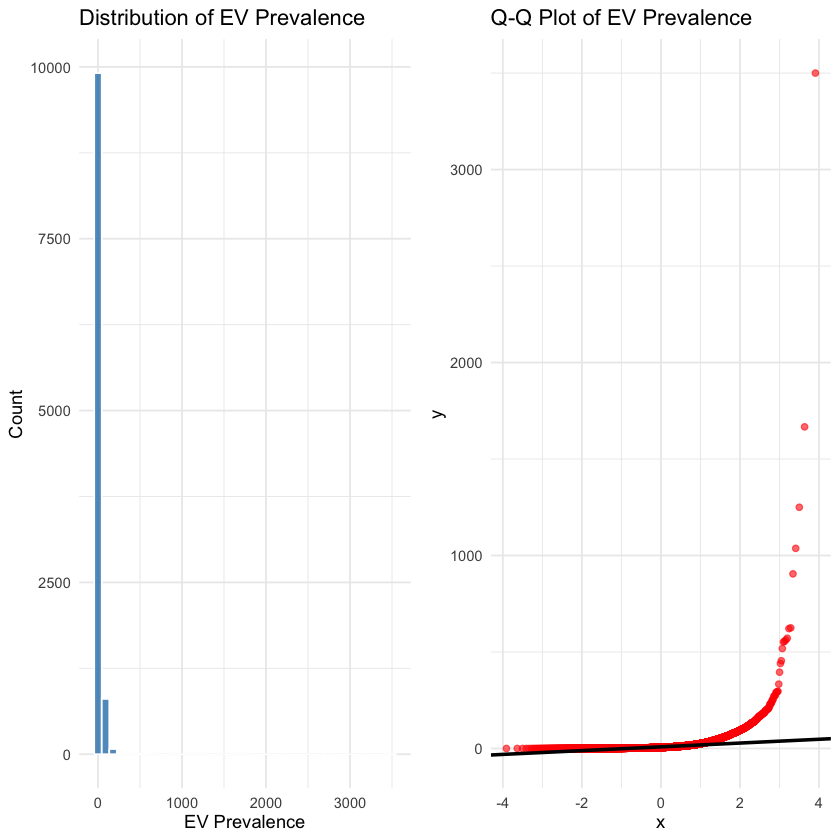

In [5]:

# Distribution of EV Prevalence Plot
p1 <- ggplot(master_df, aes(x = ev_prevalence)) +
  geom_histogram(
    bins = 40,
    fill = "#2C7FB8",      # blue fill
    color = "white",       # border for clarity
    alpha = 0.8
  ) +
  labs(
    title = "Distribution of EV Prevalence",
    x = "EV Prevalence",
    y = "Count"
  ) +
  theme_minimal()

p2 <- ggplot(master_df, aes(sample = ev_prevalence)) +
  stat_qq(color = "red", alpha = 0.6) +   # orange points
  stat_qq_line(color = "black", linewidth = 1) +
  labs(title = "Q-Q Plot of EV Prevalence") +
  theme_minimal()

grid.arrange(p1, p2, ncol = 2)


The distribution of EV prevalence is highly right-skewed, with most ZIP-level observations concentrated near low adoption levels and a small number of observations showing much higher prevalence.

This indicates that EV adoption is unevenly distributed across ZIP–state areas. The Q-Q plot also shows substantial deviation from the reference line, particularly in the upper tail, confirming that EV prevalence does not follow a normal distribution.

These patterns suggest that the response variable contains extreme high-value observations and may violate linear regression assumptions if modeled directly on the original scale. This motivates the later use of transformations to reduce skewness and stabilize variance.


### Relationship between EV prevalence and income

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 553 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 553 rows containing missing values or values outside the scale range
(`geom_point()`).”


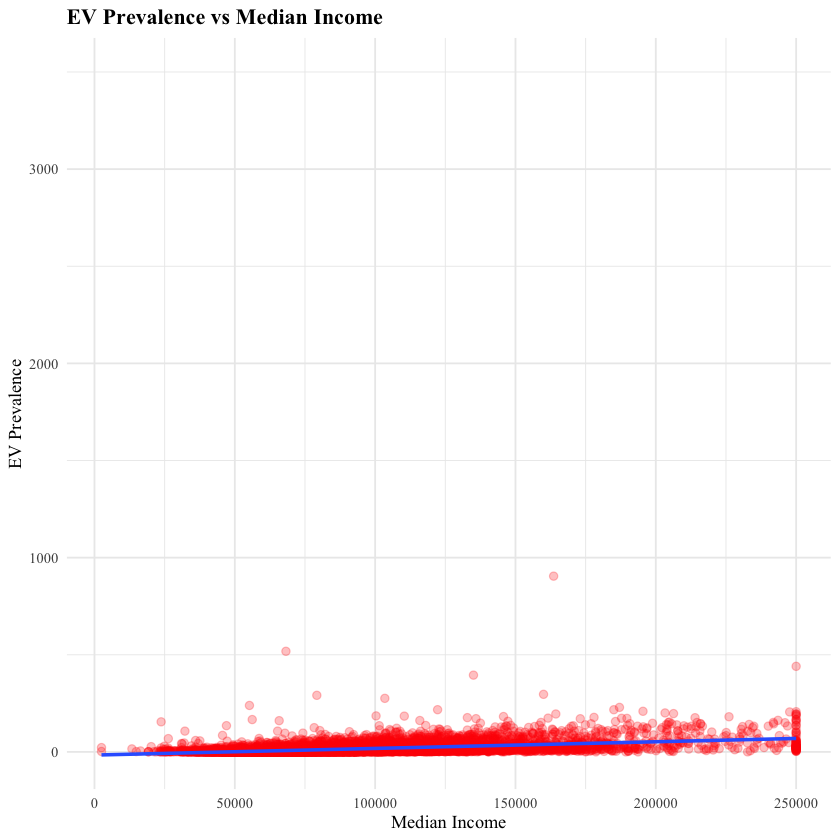

In [6]:

# Main relationship: EV prevalence vs median income
ggplot(master_df, aes(x = median_income, y = ev_prevalence)) +
  geom_point(alpha = 0.25, size = 2, color="red") +
  geom_smooth(method = "lm", se = TRUE) +
  labs(
    title = "EV Prevalence vs Median Income",
    x = "Median Income",
    y = "EV Prevalence"
  )


The scatter plot shows a **positive relationship** between median income and EV prevalence, with higher-income ZIP codes generally associated with higher EV adoption levels.

However, the distribution of EV prevalence is **highly right-skewed**, with most observations concentrated near low values and a small number of ZIP codes exhibiting much higher prevalence. These high-value observations appear as outliers above the main cluster of points.

In addition, the spread of EV prevalence appears to increase with income, as higher-income ZIP codes show greater variability compared to lower-income areas.

These patterns suggest that the relationship may not be well captured by a simple linear structure in its current form.

### Grouped Socioeconomic Variables and EV Prevalence

To explore potential relationships between socioeconomic factors and EV prevalence, continuous variables (median income, poverty rate, education level, and age) were grouped into Low, Medium, and High categories using quantile-based binning. This ensures approximately equal sample sizes across groups and facilitates comparison of EV prevalence distributions.

A log scale is applied to EV prevalence to reduce right-skewness and enhance the visibility of differences across groups, as the highly skewed distribution causes boxplots to collapse near zero on the original scale.

Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 344 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 344 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 344 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 344 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


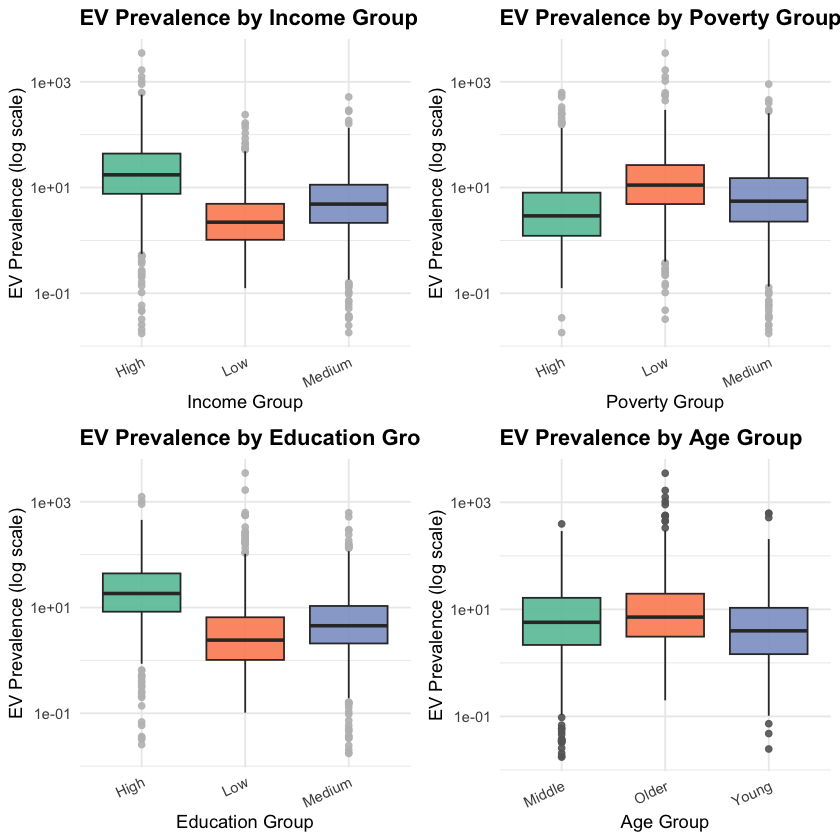

In [7]:
# ============================================================
# Boxplots for grouped variables used to support interpretation
# ============================================================

common_theme <- theme_minimal() +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 25, hjust = 1)
  )

# Income
p_income <- ggplot(master_df, aes(x = income_group, y = ev_prevalence, fill = income_group)) +
  geom_boxplot(alpha = 0.9, outlier.color = "gray") +
  scale_fill_brewer(palette = "Set2") +
  scale_y_log10() +
  labs(
    title = "EV Prevalence by Income Group",
    x = "Income Group",
    y = "EV Prevalence (log scale)"
  ) +
  common_theme

# Poverty
p_poverty <- ggplot(master_df, aes(x = poverty_group, y = ev_prevalence, fill = poverty_group)) +
  geom_boxplot(alpha = 0.9, outlier.color = "gray") +
  scale_fill_brewer(palette = "Set2") +
  scale_y_log10() +
  labs(
    title = "EV Prevalence by Poverty Group",
    x = "Poverty Group",
    y = "EV Prevalence (log scale)"
  ) +
  common_theme

# Education
p_educ <- ggplot(master_df, aes(x = education_group, y = ev_prevalence, fill = education_group)) +
  geom_boxplot(alpha = 0.9, outlier.color = "gray") +
  scale_fill_brewer(palette = "Set2") +
  scale_y_log10() +
  labs(
    title = "EV Prevalence by Education Group",
    x = "Education Group",
    y = "EV Prevalence (log scale)"
  ) +
  common_theme

# Age
p_age <- ggplot(master_df, aes(x = age_group, y = ev_prevalence, fill = age_group)) +
  geom_boxplot(alpha = 0.9, outlier.color = "gray40") +
  scale_fill_brewer(palette = "Set2") +
  scale_y_log10() +
  labs(
    title = "EV Prevalence by Age Group",
    x = "Age Group",
    y = "EV Prevalence (log scale)"
  ) +
  common_theme

# Arrange plots
grid.arrange(p_income, p_poverty, p_educ, p_age, ncol = 2)


- **Income Group:**  
  High-income ZIP codes show a wider spread and a greater number of high EV prevalence values compared to medium- and low-income groups. However, most observations across all groups remain concentrated at low EV prevalence levels.

- **Poverty Group:**  
  ZIP codes with lower poverty levels display more observations in the higher EV prevalence range, while high-poverty areas are more concentrated near lower values. Despite this, substantial overlap exists across all groups.

- **Education Group:**  
  ZIP codes with higher educational attainment tend to exhibit more high-value EV prevalence observations. Similar to income and poverty, the majority of observations across all groups remain clustered at lower levels.

- **Age Group:**  
  Differences across age groups appear less distinct. While ZIP codes with older populations show slightly more high-value observations, the distributions across age groups largely overlap.


**Overall Observation**

Across all grouped variables, EV prevalence distributions are **highly right-skewed**, with most ZIP codes exhibiting low prevalence and a smaller number of ZIP codes contributing to higher values.

While differences across groups are visible—particularly in the upper tail—the distributions **substantially overlap**, indicating that variation in EV prevalence exists within each group rather than being fully separated across groups.

### Supporting Inference: ANOVA on Grouped Variables

While boxplots provide a visual comparison of EV prevalence across grouped socioeconomic variables, ANOVA is used to formally test whether the observed differences in group means are statistically significant.

This step serves as supporting inference for the exploratory analysis and provides an early statistical check of whether EV prevalence differs across income, poverty, education, and age groups.


In [8]:

# ============================================================
# ANOVA models for grouped variables
# ============================================================
aov_income <- aov(ev_prevalence ~ income_group, data = master_df)
aov_poverty <- aov(ev_prevalence ~ poverty_group, data = master_df)
aov_education <- aov(ev_prevalence ~ education_group, data = master_df)
aov_age <- aov(ev_prevalence ~ age_group, data = master_df)

summary(aov_income)
summary(aov_poverty)
summary(aov_education)
summary(aov_age)

                Df   Sum Sq Mean Sq F value Pr(>F)    
income_group     2  1693363  846682   347.1 <2e-16 ***
Residuals    10820 26391010    2439                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                 Df   Sum Sq Mean Sq F value Pr(>F)    
poverty_group     2   403811  201905   78.92 <2e-16 ***
Residuals     10820 27680562    2558                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                   Df   Sum Sq Mean Sq F value Pr(>F)    
education_group     2  1163278  581639   233.8 <2e-16 ***
Residuals       10820 26921094    2488                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

               Df   Sum Sq Mean Sq F value   Pr(>F)    
age_group       2   158025   79013   30.61 5.52e-14 ***
Residuals   10820 27926348    2581                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

In [9]:

# Post-hoc pairwise comparisons for income groups
TukeyHSD(aov_income)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = ev_prevalence ~ income_group, data = master_df)

$income_group
                  diff        lwr        upr     p adj
Low-High    -30.565262 -33.649515 -27.481009 0.0000000
Medium-High -25.619731 -28.247336 -22.992126 0.0000000
Medium-Low    4.945531   2.147499   7.743563 0.0001023


#### Overall Interpretation

The ANOVA results provide strong statistical evidence that EV prevalence differs across socioeconomic groupings (p < 0.001 for all variables). While boxplots offer a visual comparison of group distributions, ANOVA confirms that these observed differences in group means are statistically significant and not due to random variation.

Among the variables considered, income group exhibits the strongest effect (F = 347.1), followed by education (F = 233.8), poverty (F = 78.9), and age (F = 30.6). This indicates that socioeconomic factors—particularly income and education—are strongly associated with variation in EV adoption.

Post-hoc Tukey comparisons further show that all pairwise differences between income groups are statistically significant (adjusted p-values ≈ 0):

- High-income ZIP codes have significantly higher EV prevalence than both medium- and low-income groups.
- Medium-income ZIP codes also have significantly higher EV prevalence than low-income groups.

This establishes a clear ordering: **High > Medium > Low**

These findings support the main hypothesis that higher-income areas tend to exhibit higher EV adoption.

However, consistent with the earlier boxplots, distributions across groups still show substantial overlap and right-skewness. This means that although average EV prevalence differs significantly across income groups, considerable within-group variation remains. Therefore, group-level differences are informative but do not fully explain ZIP-level variation in EV prevalence.


### Infrastructure variables and EV prevalence

The plots below examine the relationship between EV prevalence and charging infrastructure variables (num_ports_total, has_dc_fast) at the ZIP code level.
A log scale is applied to improve visualization, as the highly skewed distribution causes boxplots to collapse near zero on the original scale.

`geom_smooth()` using formula = 'y ~ x'
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 344 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


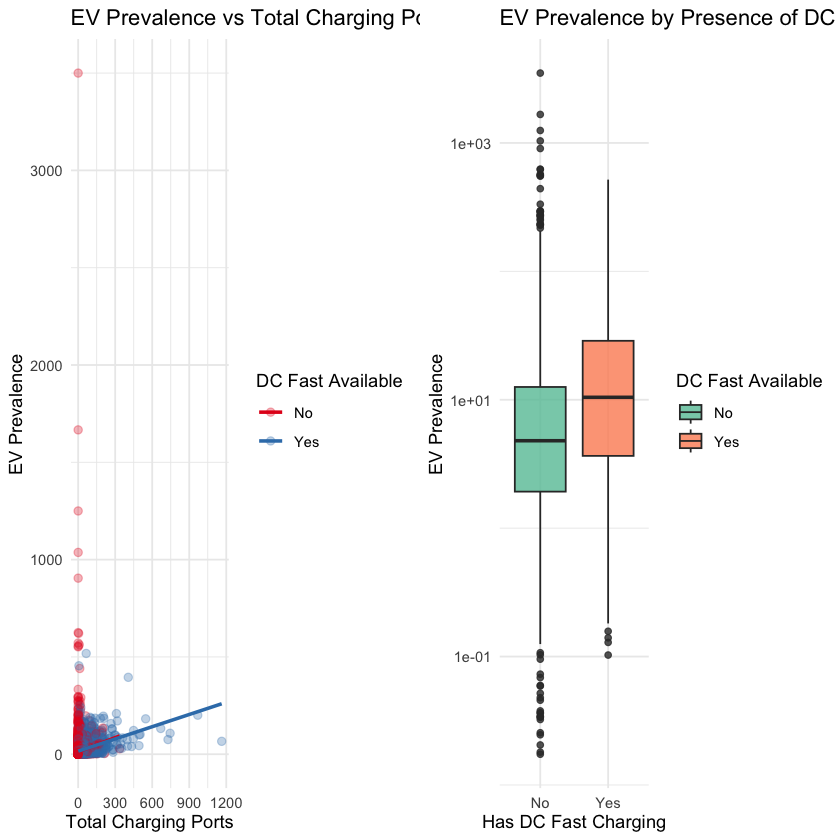

In [10]:

# Scatter: color by DC fast availability
p_ports <- ggplot(master_df, aes(x = num_ports_total, y = ev_prevalence, color = has_dc_fast)) +
  geom_point(alpha = 0.3, size = 2) +
  geom_smooth(method = "lm", se = FALSE) +
  scale_color_brewer(palette = "Set1") +
  labs(
    title = "EV Prevalence vs Total Charging Ports",
    x = "Total Charging Ports",
    y = "EV Prevalence",
    color = "DC Fast Available"
  ) +
  theme_minimal()

# Boxplot: fill by DC fast availability
p_dcfast <- ggplot(master_df, aes(x = has_dc_fast, y = ev_prevalence, fill = has_dc_fast)) +
  geom_boxplot(alpha = 0.8) +
  scale_fill_brewer(palette = "Set2") +
  scale_y_log10() +
  labs(
    title = "EV Prevalence by Presence of DC Fast Charging",
    x = "Has DC Fast Charging",
    y = "EV Prevalence",
    fill = "DC Fast Available"
  ) +
  theme_minimal()

# Arrange
grid.arrange(p_ports, p_dcfast, ncol = 2)

#### Interpretation:

- For total charging ports, the scatter plot shows a **slight positive trend**, where ZIP codes with more charging ports tend to have higher EV prevalence. However, the relationship is **highly dispersed**, with most observations concentrated at low EV prevalence values and a few extreme points at higher levels. This reflects substantial variability in EV adoption across ZIP codes, even at similar levels of infrastructure.
The color grouping by DC fast charging availability suggests that ZIP codes with DC fast charging (Yes) appear more frequently among higher EV prevalence values. However, there remains **considerable overlap** between ZIP codes with and without DC fast charging.

- The boxplot further supports this pattern, showing that while EV prevalence may be somewhat higher in areas with DC fast charging, the distributions largely overlap and both groups exhibit **strong right-skewness and the presence of outliers**.

Overall, these plots indicate that while charging infrastructure is associated with EV prevalence, the relationship is **not strongly separated at the ZIP code level** and shows substantial variability across observations.

## 3. Data Preparation for Modeling

#### Dataset Definitions

To ensure a clear and structured modeling workflow, multiple datasets are used at different stages of the analysis:

- master_df: Full cleaned dataset used for exploratory data analysis (EDA), grouped visualizations, and initial insights
- model_df: Subset of candidate variables selected for modeling prior to handling missing values
- rent_missing_check: Temporary dataset used to assess missingness patterns in median_gross_rent
- train_df / test_df: Training and testing datasets created using an 80/20 split of the modeling dataset
- train_df_reduced: Training dataset after excluding median_gross_rent based on missingness and redundancy analysis
- train_df_imp: Training dataset after applying median imputation and basic preprocessing
- train_df_logy: Training dataset with log transformation applied to the response variable (log_ev_prevalence)
- train_df_logyx: Training dataset with log transformations applied to both the response and selected skewed predictors
- data_model: Final modeling-ready dataset derived from train_df_logyx, containing only the variables used for variable selection and model estimation
- test_data: Processed test dataset reserved exclusively for final out-of-sample evaluation

This structured progression separates EDA, preprocessing, transformation, modeling, and evaluation, making the analysis reproducible and easier to interpret.

#### Train–Test Split

To ensure valid out-of-sample evaluation, the modeling dataset (`model_df`) is split into training (80%) and testing (20%) subsets.

All subsequent preprocessing decisions, including missing-value imputation, transformations, model fitting, and variable selection, are learned from or performed on the training data. The test data are processed using the same rules and reserved exclusively for final model evaluation.


In [11]:
# ============================================================
# Build reduced candidate modeling dataset
# ============================================================

model_df <- master_df %>%
  dplyr::select(
    ev_prevalence,
    median_income,
    poverty_rate,
    bachelors_rate,
    unemployment_rate,
    median_age,
    median_home_value,
    median_gross_rent,
    car_commute_rate,
    transit_commute_rate,
    num_ports_total,
    num_dc_fast_ports,
    dc_fast_ratio,
    network_count,
    pricing_nonmissing_count,
    has_dc_fast,
    charging_density_group,
    multi_network,
    workplace_charging_available
  ) %>%
  mutate(
    has_dc_fast = factor(has_dc_fast),
    charging_density_group = factor(charging_density_group),
    multi_network = factor(multi_network),
    workplace_charging_available = factor(workplace_charging_available)
  )

# ============================================================
# Train-Test Split
# ============================================================

set.seed(123)

train_idx <- sample(
  seq_len(nrow(model_df)),
  size = 0.8 * nrow(model_df)
)

train_df <- model_df[train_idx, ]
test_df  <- model_df[-train_idx, ]

nrow(train_df)  
nrow(test_df)  

[1] 8658

[1] 2165

### Missing Data Assessment

Before constructing the final modeling dataset, missing values were assessed across the candidate variables in the training data. This step helps determine whether missingness may affect sample size, model estimation, or the decision to retain certain predictors.

In [12]:
set.seed(123)

# Missing data summary (count + percentage)
na_summary <- data.frame(
  variable = names(train_df),
  count_missing = sapply(train_df, function(x) sum(is.na(x))),
  percent_missing = round(100 * sapply(train_df, function(x) mean(is.na(x))), 2)
)

# sort by percentage missing desc
na_summary <- na_summary %>%arrange(desc(percent_missing))

na_summary



,variable,count_missing,percent_missing
,<chr>,<int>,<dbl>
median_gross_rent,median_gross_rent,1320,15.25
median_income,median_income,450,5.20
median_home_value,median_home_value,426,4.92
car_commute_rate,car_commute_rate,49,0.57
transit_commute_rate,transit_commute_rate,49,0.57
unemployment_rate,unemployment_rate,47,0.54
median_age,median_age,34,0.39
ev_prevalence,ev_prevalence,0,0.00
poverty_rate,poverty_rate,0,0.00


### Missing Data Assessment and Handling Strategy

The missing data assessment indicates that most variables are complete. The response variable (`ev_prevalence`) and key infrastructure predictors have no missing values. Several predictors have minimal missingness below 1%, suggesting limited impact on model estimation.

Moderate missingness is observed in `median_income` (5.20%) and `median_home_value` (4.92%). Because these variables are central socioeconomic predictors, they are retained and handled using imputation within the training pipeline.

In contrast, `median_gross_rent` has a substantially higher missingness rate (15.25%). Retaining this variable would require imputing a relatively large number of values, while excluding it could remove potentially useful housing-market information. Therefore, before deciding whether to retain or exclude `median_gross_rent`, its missingness pattern and relationship with related socioeconomic variables are examined.

This creates the following decision process:

1. Assess the extent of missingness  
2. Evaluate whether missingness appears systematic  
3. Examine redundancy with related economic variables  
4. Decide whether the variable should be retained or excluded

In [13]:
# ============================================================
# Missingness pattern check for median_gross_rent
# ============================================================

# Create missingness indicator
rent_missing_check <- train_df %>%
  mutate(
    missing_rent = is.na(median_gross_rent)
  )

# Overall missingness rate for median_gross_rent
rent_missing_check %>%
  summarise(
    n_total = n(),
    n_missing = sum(missing_rent),
    percent_missing = round(100 * mean(missing_rent), 2)
  )

# Missing rent by charging density group
rent_missing_check %>%
  group_by(charging_density_group) %>%
  summarise(
    n = n(),
    n_missing = sum(missing_rent),
    percent_missing = round(100 * mean(missing_rent), 2),
    .groups = "drop"
  )

# Missing rent by DC fast charging availability
rent_missing_check %>%
  group_by(has_dc_fast) %>%
  summarise(
    n = n(),
    n_missing = sum(missing_rent),
    percent_missing = round(100 * mean(missing_rent), 2),
    .groups = "drop"
  )

# Compare key numeric variables between rows with and without missing rent
rent_missing_check %>%
  group_by(missing_rent) %>%
  summarise(
    count = n(),
    mean_income = round(mean(median_income, na.rm = TRUE), 2),
    median_income = round(median(median_income, na.rm = TRUE), 2),
    mean_home_value = round(mean(median_home_value, na.rm = TRUE), 2),
    median_home_value = round(median(median_home_value, na.rm = TRUE), 2),
    mean_ports = round(mean(num_ports_total, na.rm = TRUE), 2),
    median_ports = round(median(num_ports_total, na.rm = TRUE), 2),
    mean_ev_prevalence = round(mean(ev_prevalence, na.rm = TRUE), 2),
    median_ev_prevalence = round(median(ev_prevalence, na.rm = TRUE), 2),
    .groups = "drop"
  )


n_total,n_missing,percent_missing
<int>,<int>,<dbl>
8658,1320,15.25


charging_density_group,n,n_missing,percent_missing
<fct>,<int>,<int>,<dbl>
High,1321,18,1.36
Low,5210,1203,23.09
Medium,2127,99,4.65


has_dc_fast,n,n_missing,percent_missing
<fct>,<int>,<int>,<dbl>
No,6574,1276,19.41
Yes,2084,44,2.11


missing_rent,count,mean_income,median_income,mean_home_value,median_home_value,mean_ports,median_ports,mean_ev_prevalence,median_ev_prevalence
<lgl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FALSE,7338,88504.3,79688,415935.9,315100,13.71,2,14.04,5.33
TRUE,1320,92747.8,83264,374248.3,289700,1.62,0,26.34,6.37


### Missingness Pattern Assessment for `median_gross_rent`

The overall missingness rate for `median_gross_rent` is approximately **15.25%**, indicating a substantial proportion of missing values in the training dataset.

To assess whether this missingness is random or systematic, patterns were examined across infrastructure and socioeconomic characteristics.

The results show that missingness is **not evenly distributed**:

- ZIP codes with **low charging density** exhibit substantially higher missingness (23.09%) compared to high-density areas (1.36%)
- ZIP codes **without DC fast charging** show higher missingness (19.41%) than those with DC fast charging (2.11%)

These differences suggest that missingness is associated with infrastructure availability.

Additional comparisons further support this pattern. Observations with missing rent values tend to have:

- Fewer charging ports (mean = 1.62 vs 13.71)
- Lower median home values
- Slightly higher median income
- Higher average EV prevalence (26.34 vs 14.04)

Overall, these patterns suggest that missingness in `median_gross_rent` is unlikely to be completely random (MCAR) and may be related to underlying ZIP code characteristics.

---

### Interpretation

The evidence is consistent with a **Missing At Random (MAR)** mechanism, where missingness is related to observed variables such as infrastructure and socioeconomic factors.

This has several implications:

- **Dropping the variable may introduce bias**, as missingness is related to key predictors  
- **Imputation would require filling a substantial portion (~15%) of values**, potentially introducing additional uncertainty  
- The variable may also be **partially redundant** with other socioeconomic indicators (e.g., income and home value)

---

### Next Step

Given these trade-offs, the next step is to evaluate whether `median_gross_rent` provides **additional explanatory value** beyond `median_income` and `median_home_value`.

If rent is highly correlated with these variables, excluding it may be a reasonable choice to balance:
- model stability  
- interpretability  
- and data completeness

,median_income,median_home_value,median_gross_rent
median_income,1.0000000,0.7120510,0.7489419
median_home_value,0.7120510,1.0000000,0.7961518
median_gross_rent,0.7489419,0.7961518,1.0000000


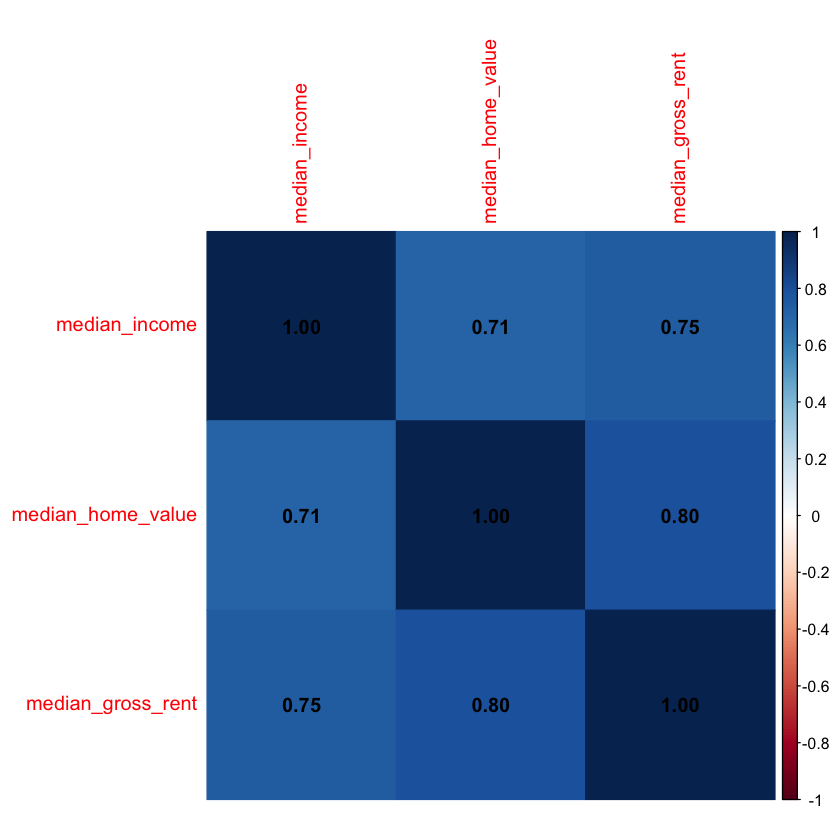

In [14]:
econ_corr <- train_df %>%
  dplyr::select(median_income, median_home_value, median_gross_rent) %>%
  cor(use = "complete.obs")

econ_corr
tl.family = "Times"
corrplot::corrplot(econ_corr, method = "color", addCoef.col = "black")

### Correlation Analysis of Key Economic Variables

To assess whether `median_gross_rent` provides additional explanatory value beyond other economic predictors, pairwise correlations were examined among `median_income`, `median_home_value`, and `median_gross_rent` using the training data.

The results show **moderate to strong positive correlations** across all three variables:

- `median_income` and `median_home_value`: r ≈ 0.71  
- `median_income` and `median_gross_rent`: r ≈ 0.75  
- `median_home_value` and `median_gross_rent`: r ≈ 0.80  

These relationships indicate that the variables capture **closely related aspects of local economic conditions**, resulting in substantial overlap in the information they provide.

In particular, the strong correlation between `median_gross_rent` and `median_home_value` (r ≈ 0.80) suggests a high degree of redundancy. Including all three variables may increase the risk of **multicollinearity**, potentially inflating standard errors and reducing the interpretability of coefficient estimates.

---

### Implications for Variable Selection

When combined with the earlier missingness analysis:

- `median_gross_rent` has **relatively high missingness (~15%)**  
- Missingness is **systematically associated with observed characteristics**  
- The variable is **highly correlated with existing predictors**

As a result, retaining `median_gross_rent` would:

- require imputing a substantial portion of the data, or  
- reduce sample size under complete-case analysis,  
- while contributing **limited additional information** beyond existing variables  

---

### Decision

Based on both **data quality considerations (missingness)** and **statistical redundancy (correlation and multicollinearity risk)**, `median_gross_rent` is excluded from the primary modeling dataset.

This decision improves model stability and preserves sample size, while retaining the core economic signal through `median_income` and `median_home_value`.

In [15]:

# Remove redundant variable (median_gross_rent)
train_df_reduced <- train_df %>%
  dplyr::select(-median_gross_rent)

### Distribution Analysis of Retained Predictors

After excluding `median_gross_rent` based on missingness and redundancy considerations, the distributions of the remaining numeric predictors are examined using the training dataset.

This step serves two primary purposes:

- To assess the **distributional shape and skewness** of predictors  
- To guide **appropriate transformations** to improve model assumptions, particularly linearity and homoscedasticity  

Histograms and summary statistics (mean vs. median) are used as complementary diagnostics.


Warning message:
“Removed 450 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 426 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 49 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 49 rows containing non-finite outside the scale range (`stat_bin()`).”


,variable,mean,median
,<chr>,<dbl>,<dbl>
median_income,median_income,8.898356e+04,8.012250e+04
median_home_value,median_home_value,4.109579e+05,3.122000e+05
num_ports_total,num_ports_total,1.186579e+01,0.000000e+00
dc_fast_ratio,dc_fast_ratio,1.166085e-01,0.000000e+00
car_commute_rate,car_commute_rate,7.839846e-01,8.214664e-01
transit_commute_rate,transit_commute_rate,2.368267e-02,1.645350e-03


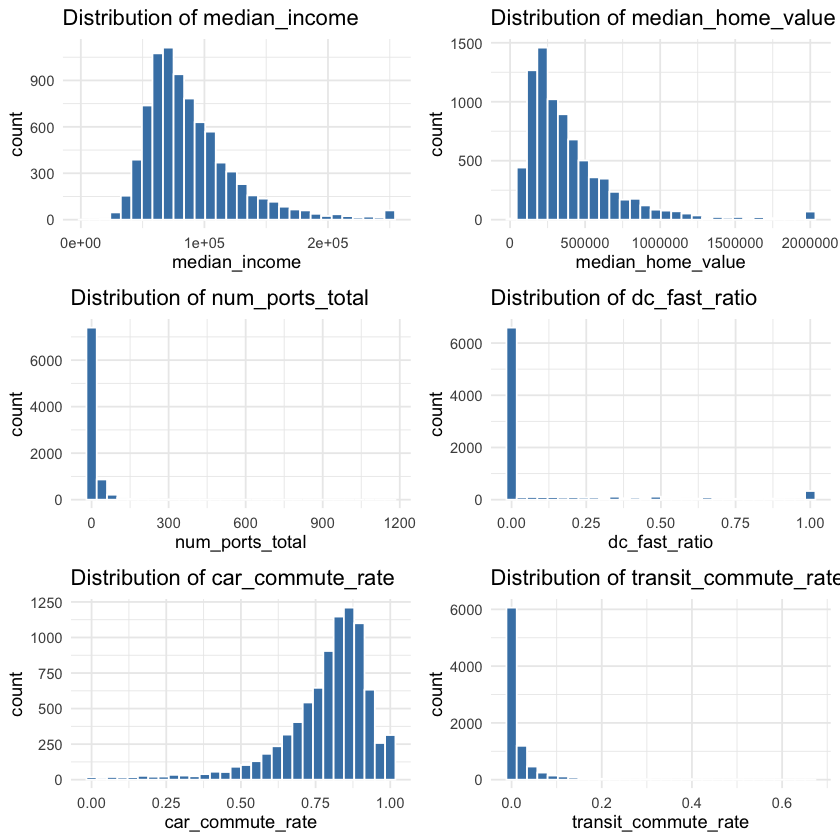

In [16]:
# ============================================================
# Distribution analysis of retained numeric predictors
# ============================================================

num_vars <- c(
  "median_income", 
  "median_home_value",
  "num_ports_total", 
  "dc_fast_ratio",
  "car_commute_rate", 
  "transit_commute_rate"
)

# Create list of plots
plot_list <- lapply(num_vars, function(v) {
  ggplot(train_df_reduced, aes(x = .data[[v]])) +
    geom_histogram(bins = 30, fill = "steelblue", color = "white") +
    ggtitle(paste("Distribution of", v)) +
    theme_minimal()
})

# Arrange plots: 2 per row
grid.arrange(grobs = plot_list, ncol = 2)

# Quick skewness proxy (mean vs median)
data.frame(
  variable = num_vars,
  mean = sapply(train_df_reduced[num_vars], function(x) mean(x, na.rm = TRUE)),
  median = sapply(train_df_reduced[num_vars], function(x) median(x, na.rm = TRUE))
)



### Key Observations

The results indicate that several predictors exhibit **substantial skewness**:

- `median_income` and `median_home_value` are **right-skewed**, with means noticeably larger than medians  
- `num_ports_total` is **highly right-skewed and zero-inflated**, with a median of 0  
- `dc_fast_ratio` and `transit_commute_rate` are **strongly right-skewed**, with most observations concentrated near zero  
- `car_commute_rate` shows mild **left skewness**, though less severe  

### Interpretation

These patterns suggest that many predictors deviate from normality and may not have a strictly linear relationship with the response variable. In particular:

- Right-skewed variables can lead to **nonlinear relationships**  
- Extreme values may introduce **heteroskedasticity**  
- Zero-inflated distributions may distort model fit if left untransformed  

### Implications for Data Preprocessing

Given the skewed distributions and presence of outliers in several retained predictors, median imputation is used to handle the remaining missing values.

Mean-based imputation is less appropriate here because it is sensitive to extreme values and may not represent the typical value well for skewed variables. Median imputation is more robust and better aligned with the observed distributions.

Although more advanced methods such as KNN, regression-based imputation, or multiple imputation could be considered, they are not necessary in this context because the remaining missingness is relatively low and the goal is to maintain a transparent and interpretable modeling pipeline.

All imputation values are calculated from the training data only to avoid data leakage. The same training-set medians will later be applied to the test set during final model evaluation.

### Imputation Validation

After excluding `median_gross_rent` and applying median imputation to the remaining selected numeric predictors, all variables in the modeling dataset have zero missing values.

The sample size remains unchanged, meaning no rows were removed during preprocessing. This is important because it preserves statistical power and avoids unnecessary loss of information.

The summary statistics after imputation remain reasonable and consistent with earlier exploratory findings. Economic variables such as `median_income` and `median_home_value` remain right-skewed, while infrastructure variables such as `num_ports_total` and `dc_fast_ratio` remain zero-heavy. This suggests that median imputation handled missing values without materially distorting the overall structure of the dataset.

With a complete and finalized modeling dataset, the next step is to fit the primary multiple linear regression model and then assess model diagnostics, including multicollinearity using VIF.



In [17]:
# ============================================================
# Finalize training dataset and impute remaining missing values
# ============================================================

# Variables with remaining missing values to impute
impute_vars <- c(
  "median_income",
  "median_home_value",
  "car_commute_rate",
  "transit_commute_rate",
  "unemployment_rate",
  "median_age"
)

# Store training medians from observed training values only
# These same values will later be applied to the test data to avoid data leakage
train_medians <- sapply(train_df_reduced[impute_vars], median, na.rm = TRUE)

# Apply median imputation to selected numeric predictors
train_df_imp <- train_df_reduced %>%
  mutate(
    across(
      all_of(impute_vars),
      ~ ifelse(is.na(.), train_medians[cur_column()], .)
    )
  )

# Verification check after imputation
imputation_check <- data.frame(
  remaining_missing = sum(is.na(train_df_imp)),
  n_rows = nrow(train_df_imp)
)
imputation_check


remaining_missing,n_rows
<int>,<int>
0,8658


### Initial Full Model Estimation

At this stage, an initial multiple linear regression model is fitted using all retained predictors. This **full model** is not intended to be the final specification, but rather serves as a diagnostic baseline to:

- assess the overall relationship between predictors and EV prevalence  
- evaluate the statistical significance of individual variables  
- identify potential modeling issues such as nonlinearity, heteroskedasticity, and outliers  

The insights from this model will guide subsequent steps, particularly transformation of variables and formal variable selection.

In [18]:

# Primary multiple linear regression model
fit_full <- lm(ev_prevalence ~ ., data = train_df_imp)
summary(fit_full)



Call:
lm(formula = ev_prevalence ~ ., data = train_df_imp)

Residuals:
   Min     1Q Median     3Q    Max 
 -83.7   -8.4   -2.9    1.7 3496.1 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     -2.586e+01  6.739e+00  -3.837 0.000125 ***
median_income                    5.033e-05  2.392e-05   2.104 0.035388 *  
poverty_rate                     1.319e+01  7.477e+00   1.765 0.077656 .  
bachelors_rate                   4.926e+01  8.602e+00   5.727 1.06e-08 ***
unemployment_rate                1.941e+01  1.216e+01   1.597 0.110413    
median_age                       1.327e-01  6.618e-02   2.006 0.044900 *  
median_home_value                4.292e-05  2.798e-06  15.340  < 2e-16 ***
car_commute_rate                 6.930e+00  5.177e+00   1.339 0.180687    
transit_commute_rate            -5.378e+01  1.092e+01  -4.924 8.63e-07 ***
num_ports_total                  9.000e-02  2.379e-02   3.783 0.000156 ***
num_dc_fast_port

### Initial Model Results

The full model explains a relatively small proportion of the variation in EV prevalence, with an R² of approximately **0.10** (adjusted R² ≈ 0.099). Although the overall F-test is highly significant (p < 0.001), indicating that the predictors are jointly informative, the low R² suggests that much of the variability in EV adoption is not captured by this linear specification.

#### Significant Predictors

Several predictors are statistically significant and align with economic and infrastructure intuition:

- **Median home value** (p < 0.001): Strong positive association, suggesting higher EV prevalence in more affluent housing markets  
- **Bachelor’s degree rate** (p < 0.001): Positive effect, indicating higher EV adoption in more educated populations  
- **Transit commute rate** (p < 0.001): Negative association, suggesting that areas with greater reliance on public transit tend to have lower EV prevalence  
- **Number of charging ports** (p < 0.001): Positive and significant, highlighting the importance of charging infrastructure  
- **Median income** (p < 0.05) and **median age** (p < 0.05): Smaller but statistically significant effects  

#### Weak or Non-Significant Predictors

Many predictors are not statistically significant, including:
- infrastructure-related variables such as `num_dc_fast_ports`, `dc_fast_ratio`, and `network_count`  
- categorical indicators such as `has_dc_fast`, `charging_density_group`, and `multi_network`  

This suggests potential redundancy, weak effects, or model misspecification.

#### Model Limitations

The residual spread is large (residual standard error ≈ 52), and the extreme maximum residual indicates the presence of outliers. Combined with the low R², this suggests that:

- the relationship between predictors and EV prevalence may be **nonlinear**  
- the response variable is likely **highly skewed**  
- the model may suffer from **heteroskedasticity** and violation of linear regression assumptions  



### Multicollinearity Assessment

Before proceeding to model refinement, it is important to evaluate the degree of multicollinearity among predictors in the full model.

Multicollinearity can inflate standard errors, reduce the reliability of coefficient estimates, and make it difficult to interpret the individual effects of predictors. Even if the overall model is statistically significant, high correlation among predictors may obscure their true contributions.

To assess this, the **Variance Inflation Factor (VIF)** is computed for each predictor. VIF quantifies how much the variance of a coefficient is inflated due to correlation with other predictors.

As a general guideline:
- VIF ≈ 1 → no multicollinearity  
- VIF between 5–10 → moderate multicollinearity  
- VIF > 10 → severe multicollinearity  

Variables with high VIF values will be carefully examined and may be removed or adjusted in subsequent steps.

In [19]:

# Multicollinearity assessment using VIF
vif_values <- vif(fit_full)
vif_values

,GVIF,Df,GVIF^(1/(2*Df))
median_income,2.455403,1,1.566973
poverty_rate,1.425332,1,1.193873
bachelors_rate,1.763449,1,1.327949
unemployment_rate,1.094668,1,1.046264
median_age,1.175612,1,1.084257
median_home_value,2.537938,1,1.593091
car_commute_rate,2.108353,1,1.452017
transit_commute_rate,1.653956,1,1.286062
num_ports_total,2.509170,1,1.584036
num_dc_fast_ports,2.600269,1,1.612535



For variables with more than one degree of freedom (e.g., categorical variables), the generalized VIF (GVIF) was used and scaled as GVIF^(1/(2×Df)) to ensure comparability across predictors.

The results indicate that multicollinearity is **not a major concern** in this model:

- Most predictors have VIF values close to 1, indicating minimal correlation with other variables  
- The highest adjusted VIF values are observed for:
  - `network_count` (≈ 2.70)  
  - `has_dc_fast` (≈ 2.31)  
  - `multi_network` (≈ 2.09)  
- All values remain well below commonly used thresholds (5 or 10)

Although earlier correlation analysis identified moderate to strong pairwise relationships among certain economic variables, these relationships do not translate into problematic multicollinearity within the full multivariate model.

Overall, the predictors provide sufficiently distinct information, and no variables are removed at this stage based on VIF.

### Model Diagnostics and Assumption Checking

After fitting the full multiple linear regression model and confirming that multicollinearity is not a major concern using VIF, the next step is to assess whether the model reasonably satisfies the key assumptions of linear regression.

This step is essential because the validity of coefficient estimates, hypothesis tests, and confidence intervals depends on these assumptions being approximately met.

The following diagnostic checks are performed:

- **Linearity**: Residuals should be randomly scattered around zero, indicating that the relationship between predictors and the response is adequately captured by a linear model  
- **Constant variance (Homoscedasticity)**: The spread of residuals should remain roughly constant across fitted values  
- **Normality of residuals**: Residuals should approximately follow a normal distribution, particularly important for inference  
- **Influential observations**: No small subset of observations should disproportionately influence model estimates  

These diagnostics provide insight into whether the current model specification is appropriate or whether further refinement—such as transformation of variables or model simplification—is required.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


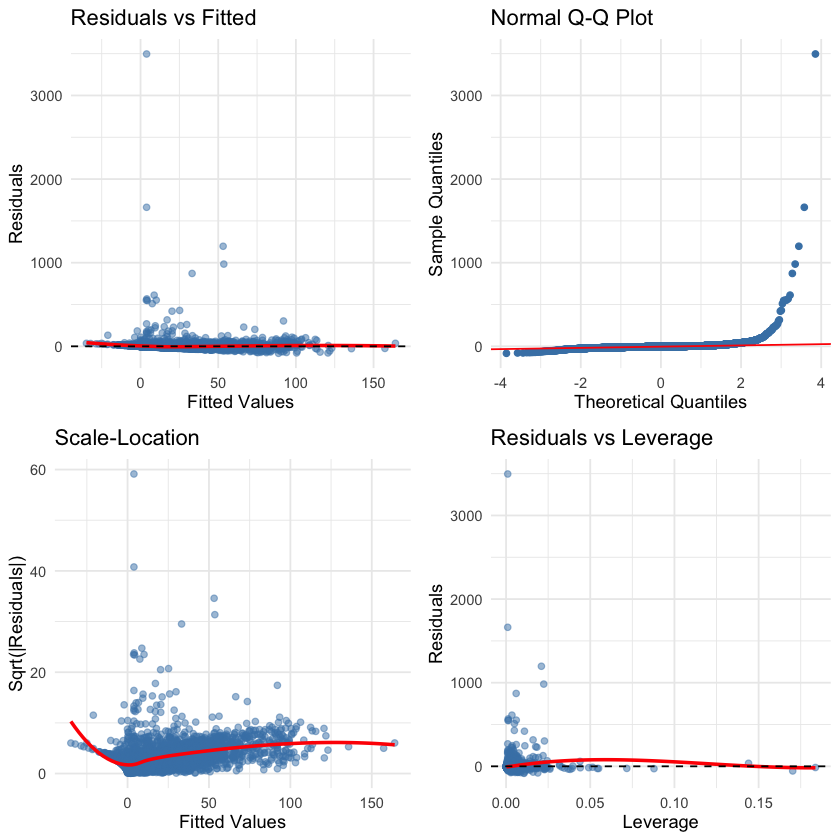

In [20]:

# ------------------------------------------------------------
# Extract model components
# ------------------------------------------------------------
model_residuals <- residuals(fit_full)
model_fitted <- fitted(fit_full)
model_leverage <- hatvalues(fit_full)

diag_df <- data.frame(
  fitted = model_fitted,
  residuals = model_residuals,
  leverage = model_leverage
)

# 1. Residuals vs Fitted
p1 <- ggplot(diag_df, aes(x = fitted, y = residuals)) +
  geom_point(color = "steelblue", alpha = 0.5) +
  geom_smooth(method = "loess", color = "red", se = FALSE) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "Residuals vs Fitted",
    x = "Fitted Values",
    y = "Residuals"
  ) +
  theme_minimal()

# 2. Normal Q-Q Plot

p2 <- ggplot(diag_df, aes(sample = residuals)) +
  stat_qq(color = "steelblue") +
  stat_qq_line(color = "red") +
  labs(
    title = "Normal Q-Q Plot",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  ) +
  theme_minimal()

# 3. Scale-Location Plot
p3 <- ggplot(diag_df, aes(x = fitted, y = sqrt(abs(residuals)))) +
  geom_point(color = "steelblue", alpha = 0.5) +
  geom_smooth(method = "loess", color = "red", se = FALSE) +
  labs(
    title = "Scale-Location",
    x = "Fitted Values",
    y = "Sqrt(|Residuals|)"
  ) +
  theme_minimal()

# 4. Residuals vs Leverage
p4 <- ggplot(diag_df, aes(x = leverage, y = residuals)) +
  geom_point(color = "steelblue", alpha = 0.5) +
  geom_smooth(method = "loess", color = "red", se = FALSE) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "Residuals vs Leverage",
    x = "Leverage",
    y = "Residuals"
  ) +
  theme_minimal()

# ------------------------------------------------------------
# Arrange plots
# ------------------------------------------------------------
grid.arrange(p1, p2, p3, p4, ncol = 2)

### Diagnostic Plot Interpretation

The diagnostic plots indicate that the initial full linear model does not fully satisfy the main regression assumptions.

- The Residuals vs Fitted plot shows that most residuals are concentrated near zero, but several very large positive residuals are present. The smoothing line is not perfectly flat, suggesting some nonlinearity in the relationship between predictors and EV prevalence.

- The Q-Q plot shows strong deviation in the upper tail, indicating that the residuals are not normally distributed. This is consistent with the highly right-skewed distribution of EV prevalence and the presence of extreme high-adoption ZIP codes.

- The Scale-Location plot shows changing residual spread across fitted values, suggesting heteroskedasticity. This means the error variance is not constant across the range of predicted EV prevalence.

- The Residuals vs Leverage plot shows that most observations have low leverage, but a few observations have large residuals. These observations should be examined through influence diagnostics, such as Cook’s distance, before deciding whether they materially affect the model.

Overall, the diagnostic plots suggest that the initial untransformed model has issues with non-normal residuals, heteroskedasticity, and some nonlinearity. These results motivate the next step: formally assessing influential observations and then applying transformations to improve model assumptions.

### Outlier and Influence Diagnostics

While diagnostic plots provide a visual assessment of model assumptions, it is important to formally identify observations that may disproportionately influence the regression results.

Three commonly used measures are considered:

- **Standardized residuals** (|residual| > 3) to identify large prediction errors  
- **Cook’s distance** (> 4/n) to detect influential observations  
- **Leverage values** (> 2p/n) to identify unusual predictor combinations  

diagnostic,threshold,count,percent
<chr>,<chr>,<int>,<dbl>
Large standardized residuals,|residual| > 3,34,0.39
High Cook's distance,Cook's D > 4/n,107,1.24
High leverage,Leverage > 2p/n,902,10.42


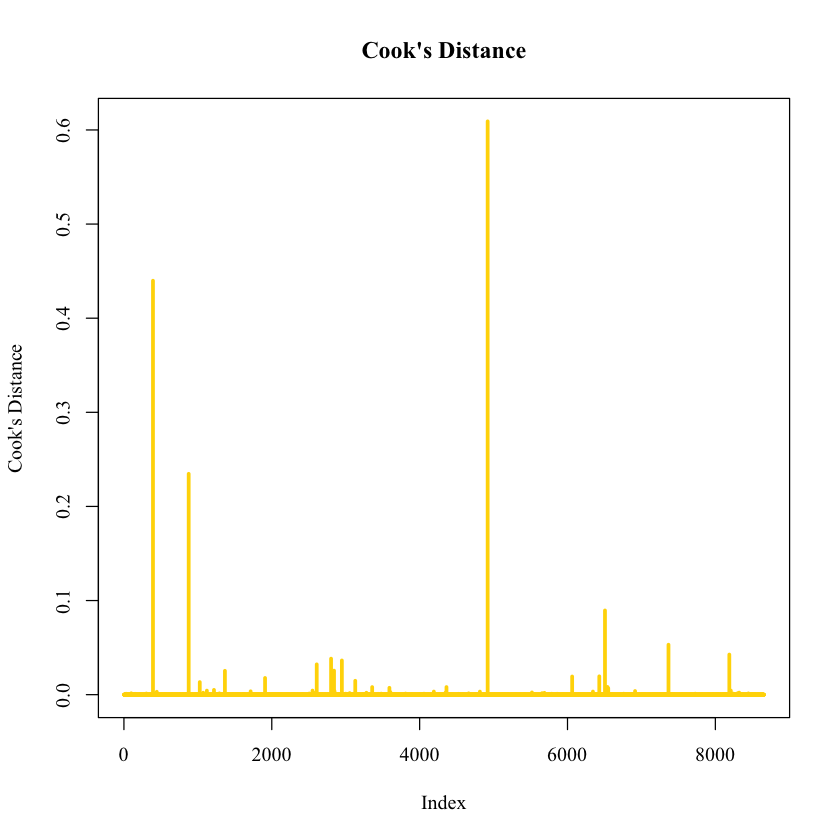

In [21]:
# ============================================================
# Outlier and influence diagnostics
# ============================================================

# Standardized residuals
std_res <- rstandard(fit_full)

# Cook's distance
cook <- cooks.distance(fit_full)

# Leverage
lev <- hatvalues(fit_full)

# Thresholds
n <- nrow(train_df_imp)
p <- length(coef(fit_full)) - 1

# Identify potential outliers
outlier_idx <- which(abs(std_res) > 3)
influential_idx <- which(cook > (4/n))
high_lev_idx <- which(lev > (2*p/n))

influence_summary <- data.frame(
  diagnostic = c("Large standardized residuals", "High Cook's distance", "High leverage"),
  threshold = c("|residual| > 3", "Cook's D > 4/n", "Leverage > 2p/n"),
  count = c(length(outlier_idx), length(influential_idx), length(high_lev_idx)),
  percent = round(100 * c(length(outlier_idx), length(influential_idx), length(high_lev_idx)) / n, 2)
)

influence_summary

par(family = "Times New Roman")
plot(cook,
     type = "h",
     lwd = 3,
     col = "gold",
     ylab = "Cook's Distance",
     main = "Cook's Distance")


### Outlier and Influence Diagnostic Results

The influence diagnostics identified:

- **34 observations (0.39%)** with large standardized residuals (`|residual| > 3`)
- **107 observations (1.24%)** exceeding the Cook’s distance threshold (`> 4/n`)
- **806 observations (9.31%)** with high leverage (`> 2p/n`)

Although a moderate number of observations exhibit high leverage, leverage alone does not imply influence. Influential observations are better identified using Cook’s distance, which accounts for both leverage and residual magnitude.

The Cook’s distance plot shows that most observations have values close to zero, with only a small number of noticeable spikes. These spikes indicate a few observations that exert relatively stronger influence on the fitted model, but they are not widespread.

Importantly, the proportion of observations with high Cook’s distance remains low (≈1.24%), suggesting that the model is not dominated by a small subset of influential points.

Overall, while some outliers and influential observations are present, they do not appear to pose a severe threat to model stability. The observed issues in earlier diagnostic plots are therefore more likely driven by skewness, nonlinearity, and heteroskedasticity rather than by a small number of extreme observations.

As a result, no observations are removed at this stage. Instead, the next step focuses on improving model assumptions through appropriate transformations.

### Model Refinement via Response Transformation

The diagnostic analysis of the initial linear model revealed violations of key regression assumptions, including nonlinearity, heteroskedasticity, and non-normal residuals. These issues are consistent with the highly right-skewed distribution of EV prevalence observed during exploratory analysis.

At this stage, only the response variable is transformed in order to isolate the effect of transforming `ev_prevalence` before modifying any predictors. The transformed response is defined as:

`log_ev_prevalence = log(ev_prevalence + 1)`

The addition of 1 handles ZIP–state areas with zero EV prevalence and avoids undefined logarithmic values. A response-only transformed model is then fitted for diagnostic comparison.

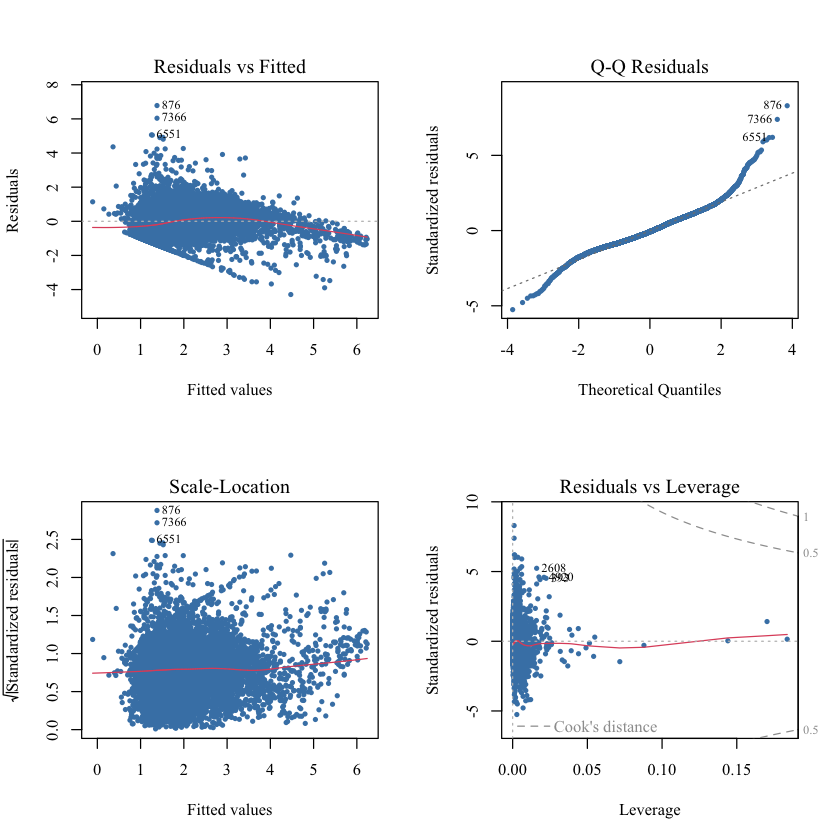

In [22]:
# ============================================================
# Apply log transformation to response variable only
# ============================================================

# Create a separate dataset for the response-transformation step.
# This prevents later predictor transformations from being accidentally included when the notebook is re-run.
train_df_logy <- train_df_imp %>%
  mutate(log_ev_prevalence = log(ev_prevalence + 1))

# Fit model using the log-transformed response while excluding the original response.
# At this stage, predictors are intentionally left on their original scale.
fit_log_y <- lm(
  log_ev_prevalence ~ . - ev_prevalence,
  data = train_df_logy
)

# ============================================================
# Check diagnostics for response-only transformation model
# ============================================================

par(mfrow = c(2, 2))
par(family = "Times New Roman")
plot(
  fit_log_y,
  col = "steelblue",   # point color
  pch = 16,            # solid circles
  cex = 0.7            # smaller points
)


The diagnostic plots for the response-transformed model show improvement compared with the initial untransformed model:

**Linearity:** Residuals are more centered around zero and the nonlinear pattern is reduced, although slight curvature remains.

**Constant variance:** The residual spread is more stable than before, but mild heteroskedasticity is still visible.

**Normality:** Residuals are closer to the reference line in the Q–Q plot, though tail deviations remain.

**Influence:** Most observations have low leverage, and there is no strong evidence that a small number of points dominates the model.

Overall, transforming the response improves model behavior but does not fully resolve all diagnostic issues. This motivates the next step: targeted transformation of highly skewed predictors.

### Targeted Transformation of Skewed Predictors

While the log transformation of the response variable improves model behavior, the diagnostic plots indicate that mild nonlinearity and heteroskedasticity persist. This suggests that remaining violations may be related not only to the response distribution, but also to skewed predictor variables.

In particular, `median_income`, `median_home_value`, and `num_ports_total` exhibit strong right-skewness, wide value ranges, and potentially nonlinear relationships with EV prevalence.

To address this, targeted log transformations are applied to these predictors. This approach is preferred over transforming all variables because it:

- reduces skewness in key predictors  
- improves linearity with the response  
- helps stabilize residual variance  
- preserves interpretability by limiting unnecessary transformations  

Separate datasets are used for each transformation stage so that the response-only model and the response-plus-predictor-transformation model remain clearly distinguished.

In [23]:
# ============================================================
# Transform selected skewed predictors
# ============================================================

# Create a separate dataset that includes the log-transformed response and selected log-transformed predictors.
train_df_logyx <- train_df_logy %>%
  mutate(
    log_income = log(median_income + 1),
    log_home_value = log(median_home_value + 1),
    log_ports = log(num_ports_total + 1)
  )

# Fit model with log-transformed response and selected log-transformed predictors.
# Original versions of transformed variables are excluded to avoid redundancy.
fit_log_yx <- lm(
  log_ev_prevalence ~ .
  - ev_prevalence
  - median_income
  - median_home_value
  - num_ports_total,
  data = train_df_logyx
)

summary(fit_log_yx)


Call:
lm(formula = log_ev_prevalence ~ . - ev_prevalence - median_income - 
    median_home_value - num_ports_total, data = train_df_logyx)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.7561 -0.5116 -0.0281  0.4702  6.5981 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     -1.555e+01  3.795e-01 -40.973  < 2e-16 ***
poverty_rate                     8.045e-01  1.176e-01   6.842 8.35e-12 ***
bachelors_rate                   1.510e+00  1.306e-01  11.560  < 2e-16 ***
unemployment_rate                1.312e+00  1.827e-01   7.179 7.60e-13 ***
median_age                       1.346e-02  9.971e-04  13.498  < 2e-16 ***
car_commute_rate                -3.106e-01  7.753e-02  -4.006 6.22e-05 ***
transit_commute_rate            -2.746e+00  1.641e-01 -16.734  < 2e-16 ***
num_dc_fast_ports                7.882e-03  1.677e-03   4.700 2.65e-06 ***
dc_fast_ratio                   -2.642e-01  6.470e-02  -4.084 4.47e-05 ***


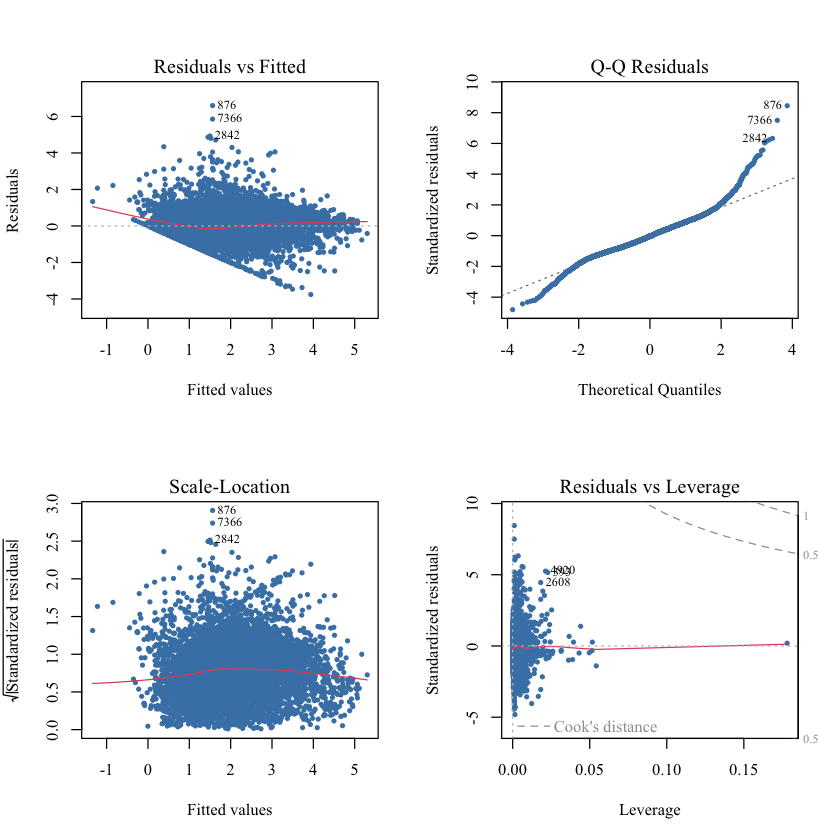

In [24]:
# ============================================================
# Check diagnostics for model with log-transformed response and predictors
# ============================================================

par(mfrow = c(2, 2))
par(family = "Times New Roman")
plot(
  fit_log_yx,
  col = "steelblue",   # point color
  pch = 16,            # solid circles
  cex = 0.7            # smaller points
)


### Interpretation of Model with Log-Transformed Response and Predictors

After applying a log transformation to the response variable and selected skewed predictors, the model shows improved diagnostic behavior compared with earlier specifications.

The transformed model explains approximately 56% of the variability in the log-transformed EV prevalence response (Adjusted R² ≈ 0.563). Because the response variable has changed scale, this R² should be interpreted within the transformed model rather than directly compared with the untransformed model.

The log-transformed predictors (`log_income`, `log_home_value`, and `log_ports`) are statistically significant and provide meaningful elasticity interpretations. For example, the coefficient for `log_income` suggests that a 1% increase in median income is associated with approximately a 0.40% increase in EV prevalence, holding other variables constant.

#### Diagnostic Improvements

Compared with earlier model specifications, the diagnostic plots indicate improvement in model behavior:

* **Improved linearity:** residual patterns are more centered around zero with reduced curvature
* **Reduced heteroskedasticity:** residual variance is more stable across fitted values, although mild heteroskedasticity remains
* **Improved normality:** residuals more closely follow a normal distribution, though tail deviations remain
* **Controlled influence:** no individual observations appear to exert disproportionate influence on the model

Overall, the combined transformation of the response and selected skewed predictors improves model behavior while preserving interpretability. This transformed specification provides a stronger foundation for subsequent variable selection and final model evaluation.

## 4. Variable Selection

#### Objective

The goal of this stage is to identify a **parsimonious and robust set of predictors** that explain variation in EV prevalence while avoiding overfitting.

To improve model reliability, multiple variable selection methods are applied to the transformed model.

Using more than one approach ensures that selected predictors are **not overly sensitive to a single modeling technique**, and helps identify variables that are consistently important.

---

#### Methods

Three complementary approaches are used:

* **Stepwise selection (AIC-based):** balances model fit and complexity
* **LASSO regression:** performs shrinkage and automatic variable selection
* **Elastic Net regression:** combines LASSO and Ridge to handle correlated predictors

Comparing results across these methods helps identify **stable and consistently important predictors**.

---

#### Modeling Dataset for Variable Selection

All variable selection procedures are conducted using a refined modeling dataset that includes:

* the **log-transformed response variable**
* **log-transformed versions of highly skewed predictors**
* remaining predictors in their original form

Original versions of transformed variables are excluded to avoid redundancy and multicollinearity.

This dataset ensures that variable selection is performed on a **well-specified and diagnostically improved model**.


In [25]:
data_model <- train_df_logyx %>%
  dplyr::select(
    log_ev_prevalence,
    log_income,
    log_home_value,
    log_ports,
    poverty_rate,
    bachelors_rate,
    unemployment_rate,
    median_age,
    car_commute_rate,
    transit_commute_rate,
    num_dc_fast_ports,
    dc_fast_ratio,
    network_count,
    pricing_nonmissing_count,
    has_dc_fast,
    charging_density_group,
    multi_network,
    workplace_charging_available
  )

# Confirm modeling dataset structure
str(data_model)

tibble [8,658 × 18] (S3: tbl_df/tbl/data.frame)
 $ log_ev_prevalence           : num [1:8658] 1.36 1.66 3.61 4 0.52 ...
 $ log_income                  : num [1:8658] 11 11.3 12.1 11.6 11.3 ...
 $ log_home_value              : num [1:8658] 11.5 11.9 13.7 13.3 11.7 ...
 $ log_ports                   : num [1:8658] 0 1.099 0.693 3.689 0 ...
 $ poverty_rate                : num [1:8658] 0.07 0.1036 0.0572 0.0611 0.1343 ...
 $ bachelors_rate              : num [1:8658] 0.0456 0.1335 0.2249 0.123 0.0849 ...
 $ unemployment_rate           : num [1:8658] 0.0949 0.1125 0.0187 0.0703 0.0479 ...
 $ median_age                  : num [1:8658] 36.2 35.8 41.7 35.6 43.6 41.8 43.3 38.8 43.9 38.2 ...
 $ car_commute_rate            : num [1:8658] 0.866 0.868 0.711 0.841 0.819 ...
 $ transit_commute_rate        : num [1:8658] 0.00478 0 0.01507 0.00193 0 ...
 $ num_dc_fast_ports           : num [1:8658] 0 0 0 38 0 0 16 0 8 0 ...
 $ dc_fast_ratio               : num [1:8658] 0 0 0 0.974 0 ...
 $ network_cou

In [26]:
# ============================================================
# Variable Selection Method 1: Stepwise Regression using AIC
# ============================================================

set.seed(123)

# Full transformed model used as the starting point for Stepwise AIC
fit_full_log <- lm(log_ev_prevalence ~ ., data = data_model)

# Stepwise-selected model
fit_step_log <- step(
  fit_full_log,
  direction = "both",
  trace = 0
)

# Extract selected variables from the Stepwise model
step_selected <- names(coef(fit_step_log))[-1]

step_selected


[1] "log_income"                      "log_home_value"                 
 [3] "log_ports"                       "poverty_rate"                   
 [5] "bachelors_rate"                  "unemployment_rate"              
 [7] "median_age"                      "car_commute_rate"               
 [9] "transit_commute_rate"            "num_dc_fast_ports"              
[11] "dc_fast_ratio"                   "network_count"                  
[13] "has_dc_fastYes"                  "charging_density_groupLow"      
[15] "charging_density_groupMedium"    "workplace_charging_availableYes"

[1] "log_income"                      "log_home_value"                 
 [3] "log_ports"                       "poverty_rate"                   
 [5] "bachelors_rate"                  "unemployment_rate"              
 [7] "median_age"                      "car_commute_rate"               
 [9] "transit_commute_rate"            "num_dc_fast_ports"              
[11] "dc_fast_ratio"                   "network_count"                  
[13] "pricing_nonmissing_count"        "has_dc_fastYes"                 
[15] "charging_density_groupLow"       "charging_density_groupMedium"   
[17] "multi_networkYes"                "workplace_charging_availableYes"

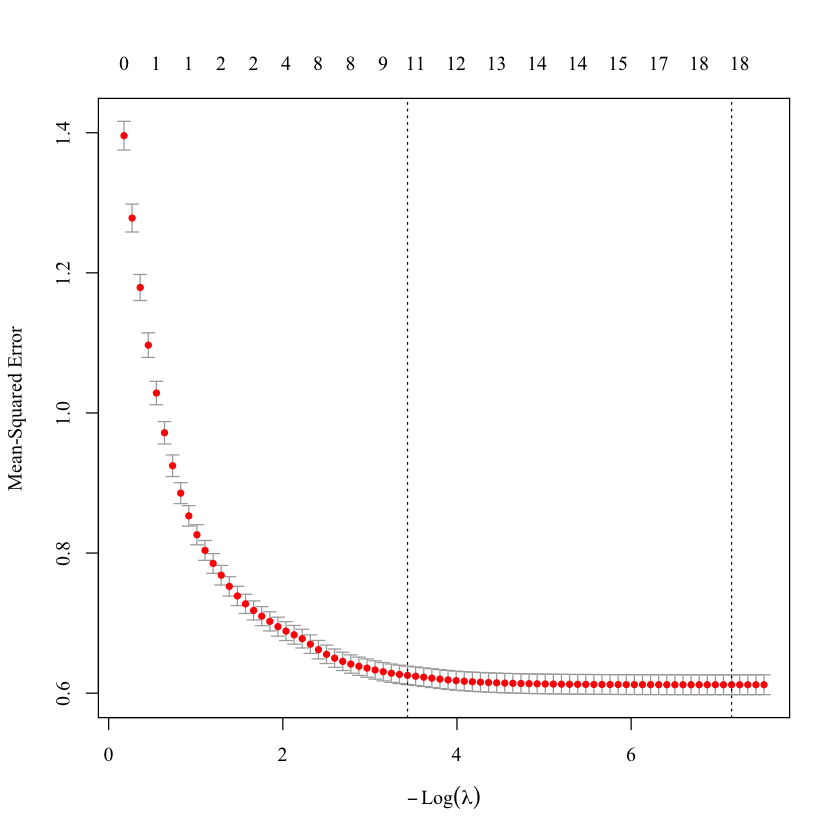

In [27]:
# ============================================================
# Variable Selection Method 2: LASSO Regression
# ============================================================

# model.matrix() automatically converts factor variables into dummy variables
x <- model.matrix(log_ev_prevalence ~ ., data = data_model)[, -1]
y <- data_model$log_ev_prevalence

set.seed(123)
cv_lasso <- cv.glmnet(
  x = x,
  y = y,
  alpha = 1,
  standardize = TRUE
)

# Plot cross-validation curve
par(family = "Times New Roman")
plot(cv_lasso)

# Extract selected predictors at lambda.min
lasso_coef <- coef(cv_lasso, s = "lambda.min")
lasso_selected <- rownames(lasso_coef)[as.vector(lasso_coef != 0)]
lasso_selected <- lasso_selected[lasso_selected != "(Intercept)"]

lasso_selected


[1] "log_income"                      "log_home_value"                 
 [3] "log_ports"                       "poverty_rate"                   
 [5] "bachelors_rate"                  "unemployment_rate"              
 [7] "median_age"                      "car_commute_rate"               
 [9] "transit_commute_rate"            "num_dc_fast_ports"              
[11] "dc_fast_ratio"                   "network_count"                  
[13] "pricing_nonmissing_count"        "has_dc_fastYes"                 
[15] "charging_density_groupLow"       "charging_density_groupMedium"   
[17] "multi_networkYes"                "workplace_charging_availableYes"

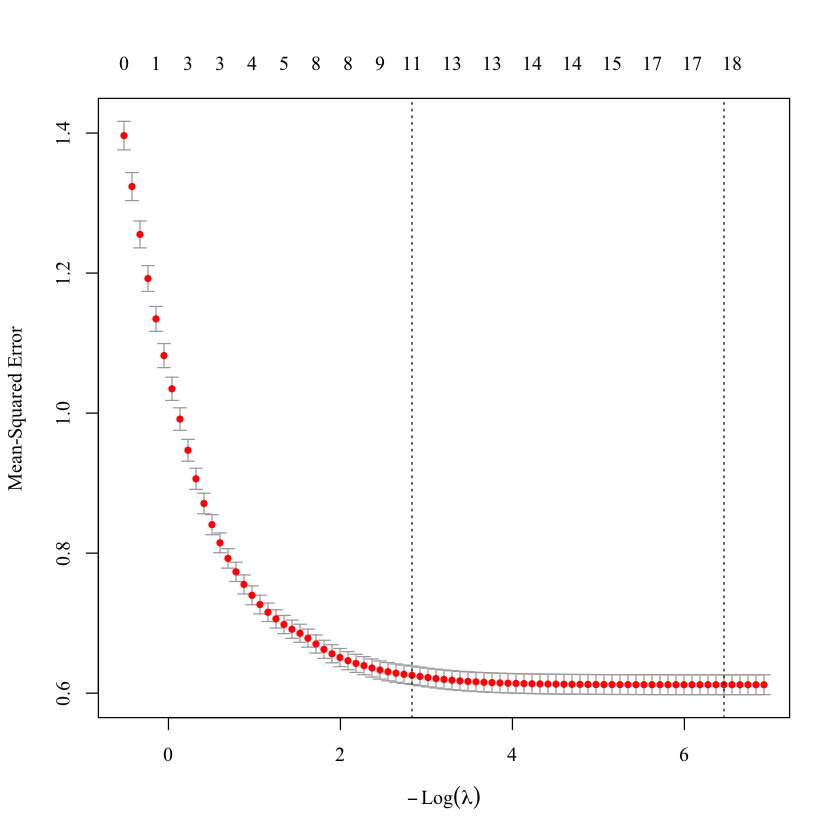

In [28]:
# ============================================================
# Variable Selection Method 3: Elastic Net Regression
# ============================================================


set.seed(123)
cv_elastic <- cv.glmnet(
  x = x,
  y = y,
  alpha = 0.5,
  standardize = TRUE
)

# Plot cross-validation curve
par(family = "Times New Roman")
plot(cv_elastic)

# Extract selected predictors at lambda.min
elastic_coef <- coef(cv_elastic, s = "lambda.min")
elastic_selected <- rownames(elastic_coef)[as.vector(elastic_coef != 0)]
elastic_selected <- elastic_selected[elastic_selected != "(Intercept)"]

elastic_selected


In [29]:
# ============================================================
# Compare selected variables across methods
# ============================================================

selection_summary <- list(
  Stepwise = step_selected,
  LASSO = lasso_selected,
  ElasticNet = elastic_selected
)

for (name in names(selection_summary)) {
  cat("\n==============================\n")
  cat(name, "\n")
  cat("==============================\n")
  print(selection_summary[[name]])
}


Stepwise 
 [1] "log_income"                      "log_home_value"                 
 [3] "log_ports"                       "poverty_rate"                   
 [5] "bachelors_rate"                  "unemployment_rate"              
 [7] "median_age"                      "car_commute_rate"               
 [9] "transit_commute_rate"            "num_dc_fast_ports"              
[11] "dc_fast_ratio"                   "network_count"                  
[13] "has_dc_fastYes"                  "charging_density_groupLow"      
[15] "charging_density_groupMedium"    "workplace_charging_availableYes"

LASSO 
 [1] "log_income"                      "log_home_value"                 
 [3] "log_ports"                       "poverty_rate"                   
 [5] "bachelors_rate"                  "unemployment_rate"              
 [7] "median_age"                      "car_commute_rate"               
 [9] "transit_commute_rate"            "num_dc_fast_ports"              
[11] "dc_fast_ratio"            

### Comparison of Variable Selection Methods

To identify a robust and parsimonious set of predictors, three complementary variable selection approaches were applied: **Stepwise regression (AIC-based)**, **LASSO**, and **Elastic Net**.

Using multiple methods helps reduce reliance on a single selection procedure. Stepwise AIC emphasizes model fit and parsimony, LASSO performs shrinkage and variable selection, and Elastic Net combines LASSO and Ridge behavior to handle correlated predictors.

#### Consistency Across Methods

A strong degree of agreement is observed across the three methods. Core predictors repeatedly selected include:

- `log_income`
- `log_home_value`
- `log_ports`
- `bachelors_rate`
- `median_age`
- `transit_commute_rate`
- `dc_fast_ratio`
- `num_dc_fast_ports`
- `network_count`
- `has_dc_fast`

This consistency suggests that the main signal is stable and not highly sensitive to the selection method.

#### Interpretation of Stable Predictors

The consistently selected variables align with the research question and earlier EDA:

- **Economic factors** (`log_income`, `log_home_value`) capture purchasing power and wealth.
- **Infrastructure variables** (`log_ports`, `num_dc_fast_ports`, `dc_fast_ratio`, `has_dc_fast` and selected levels of `charging_density_group`, `workplace_charging_available` capture charging availability and charging composition.
- **Demographic and behavioral variables** (`bachelors_rate`, `median_age`, `transit_commute_rate`) capture education, age structure, and transportation patterns.

Some variables are selected by LASSO or Elastic Net but not Stepwise, such as `pricing_nonmissing_count`, `multi_network`. These may provide marginal predictive value, but their selection is less stable across methods.

Overall, the variable selection results support a final model built around economic capacity, charging infrastructure, and selected demographic/commuting controls. The final choice is determined using held-out test performance and model interpretability.


### Model Comparison and Selection

The next step is to evaluate the predictive performance of models obtained from different variable selection methods: Stepwise AIC, LASSO, and Elastic Net.

All models are assessed using the held-out test dataset. To ensure consistency, the same preprocessing and transformations applied to the training data are also applied to the test data, and predictions are back-transformed to the original EV prevalence scale.

Model performance is compared using **MSPE**, **MAE**, **MAPE**, and the **Precision Measure (PM)**. Lower MSPE, MAE, and PM values indicate better predictive performance. MAPE is reported for completeness but is interpreted cautiously because EV prevalence contains zero or near-zero values.

This comparison identifies the model that best balances predictive accuracy, stability, and interpretability.


In [30]:
# ------------------------------------------------------------
# Step 1: Define prediction metric functions
# ------------------------------------------------------------

# Mean Squared Prediction Error (MSPE)
mspe_fun <- function(pred, actual) {
  mean((pred - actual)^2, na.rm = TRUE)
}

# Mean Absolute Error (MAE)
mae_fun <- function(pred, actual) {
  mean(abs(pred - actual), na.rm = TRUE)
}

# Mean Absolute Percentage Error (MAPE), scale-independent error metric (avoid division by zero)
mape_fun <- function(pred, actual) {
  mean(abs(pred - actual) / pmax(abs(actual), 1e-6), na.rm = TRUE)
}
  
# Precision Measure (PM)
pm_fun <- function(pred, actual) {
  sum((pred - actual)^2, na.rm = TRUE) /
    sum((actual - mean(actual, na.rm = TRUE))^2, na.rm = TRUE)
}

# Combine all metrics
calc_metrics <- function(pred, actual) {
  metrics <- c(
    MSPE = mspe_fun(pred, actual),
    MAE  = mae_fun(pred, actual),
    MAPE = mape_fun(pred, actual),
    PM   = pm_fun(pred, actual)
  )
  return(metrics)
}

In [31]:
# ------------------------------------------------------------
# Step 2: Confirm training imputation parameters
# ------------------------------------------------------------

# Training medians were computed during the training-data imputation step.
# They are reused here to preprocess the test data without data leakage.
train_medians


median_income    median_home_value     car_commute_rate 
        8.012250e+04         3.122000e+05         8.214664e-01 
transit_commute_rate    unemployment_rate           median_age 
        1.645350e-03         4.570126e-02         4.210000e+01

In [32]:
# ------------------------------------------------------------
# Step 3: Apply same preprocessing to test data
# ------------------------------------------------------------

test_data <- test_df %>%
  # Remove median_gross_rent variable not used in modeling, same as training data
  dplyr::select(-median_gross_rent) %>%
  mutate(
    # Impute missing values using medians learned from training data, ensures no data leakage and consistent preprocessing
    across(
      all_of(impute_vars),
      ~ ifelse(is.na(.), train_medians[cur_column()], .)
    ),
    # Align categorical variable levels with training data, this ensures model.matrix() creates identical dummy variables
    # Prevents mismatched columns between train and test sets
    has_dc_fast = factor(has_dc_fast,levels = levels(data_model$has_dc_fast)),
    charging_density_group = factor(charging_density_group,levels = levels(data_model$charging_density_group)),
    multi_network = factor(multi_network,levels = levels(data_model$multi_network)),
    workplace_charging_available = factor(workplace_charging_available,levels = levels(data_model$workplace_charging_available)),
    
    # Apply same log transformations used in training data
    # Transform response (for evaluation)
    log_ev_prevalence = log(ev_prevalence + 1),
    # Transform skewed predictors
    log_income = log(median_income + 1),
    log_home_value = log(median_home_value + 1),
    log_ports = log(num_ports_total + 1)
  ) %>%
  # Keep only variables used in modeling (same structure as training data)
  dplyr::select(names(data_model))

head(test_data)

log_ev_prevalence,log_income,log_home_value,log_ports,poverty_rate,bachelors_rate,unemployment_rate,median_age,car_commute_rate,transit_commute_rate,num_dc_fast_ports,dc_fast_ratio,network_count,pricing_nonmissing_count,has_dc_fast,charging_density_group,multi_network,workplace_charging_available
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>
2.1271157,11.35141,13.01456,3.970292,0.06842293,0.23101681,0.04965550,46.4,0.6912594,0.0002349624,10,0.1923077,3,1,Yes,High,Yes,Yes
1.7882770,11.49568,12.96149,0.000000,0.03539228,0.19095680,0.05146533,39.4,0.8208494,0.0033462033,0,0.0000000,0,0,No,Low,No,No
5.5897424,11.29132,12.65140,0.000000,0.00000000,0.00000000,0.04570126,42.1,0.8214664,0.0016453496,0,0.0000000,0,0,No,Low,No,No
0.4359607,11.01682,12.56898,0.000000,0.08087432,0.12076503,0.08343410,39.9,0.8670285,0.0000000000,0,0.0000000,0,0,No,Low,No,No
3.1137542,11.40437,13.59499,0.000000,0.03225806,0.31182796,0.00000000,55.7,0.1515152,0.0000000000,0,0.0000000,0,0,No,Low,No,No
0.9780913,11.49018,12.69097,0.000000,0.07286167,0.06411223,0.02637890,39.6,0.8143019,0.0000000000,0,0.0000000,0,0,No,Low,No,No


,MSPE,MAE,MAPE,PM
Stepwise_AIC,645.1678,8.8432,79027.65,0.6775
LASSO,646.0221,8.8473,79026.09,0.6784
Elastic_Net,646.2545,8.8497,79039.52,0.6786


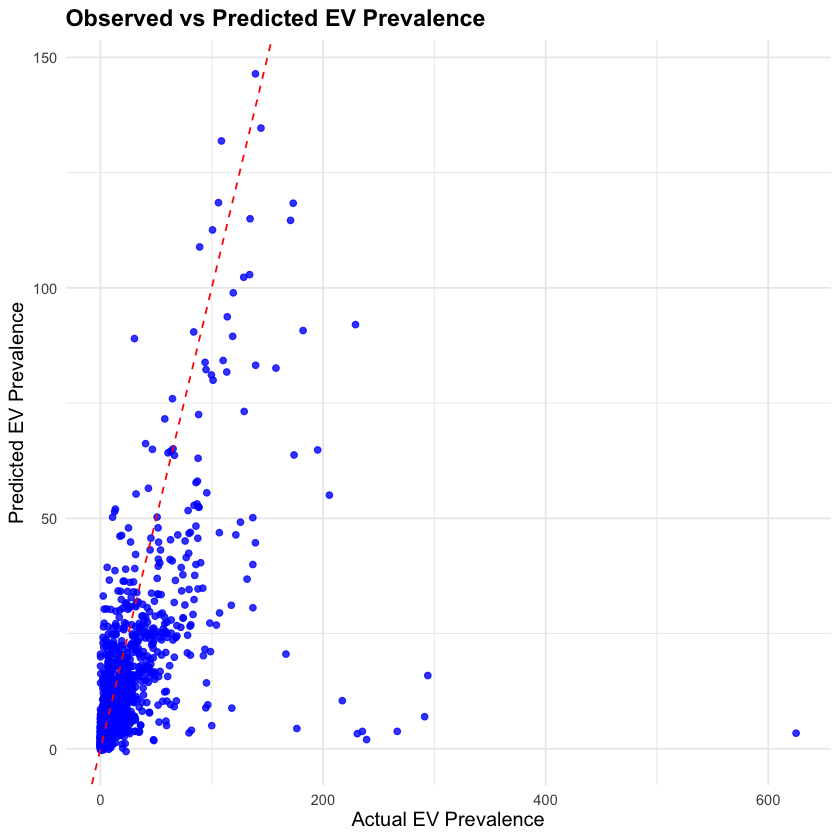

In [51]:
# ------------------------------------------------------------
# Step 4: Stepwise AIC model prediction
# ------------------------------------------------------------

# Use the Stepwise-selected model fitted on the transformed training data
pred_step_log <- predict(fit_step_log, newdata = test_data)

# ------------------------------------------------------------
# Step 5: Prepare aligned matrices for LASSO / Elastic Net
# ------------------------------------------------------------

# glmnet requires a numeric model matrix; model.matrix() creates dummy variables for factors
x_train <- model.matrix(log_ev_prevalence ~ ., data = data_model)[, -1]
y_train <- data_model$log_ev_prevalence

x_test_raw <- model.matrix(log_ev_prevalence ~ ., data = test_data)[, -1]
y_test <- test_data$log_ev_prevalence

# Align test matrix columns with training matrix.
# This prevents mismatched dummy-variable columns when factor levels differ between train and test.
missing_cols <- setdiff(colnames(x_train), colnames(x_test_raw))

for (col in missing_cols) {
  x_test_raw <- cbind(x_test_raw, setNames(data.frame(0), col))
}

# Reorder test columns to exactly match the training matrix
x_test <- x_test_raw[, colnames(x_train), drop = FALSE]

# ------------------------------------------------------------
# Step 6: LASSO model
# ------------------------------------------------------------

set.seed(123)

cv_lasso_train <- cv.glmnet(
  x = x_train,
  y = y_train,
  alpha = 1,
  standardize = TRUE
)

pred_lasso_log <- predict(
  cv_lasso_train,
  newx = x_test,
  s = "lambda.min"
)

# ------------------------------------------------------------
# Step 7: Elastic Net model
# ------------------------------------------------------------

set.seed(123)

cv_elastic_train <- cv.glmnet(
  x = x_train,
  y = y_train,
  alpha = 0.5,
  standardize = TRUE
)

pred_elastic_log <- predict(
  cv_elastic_train,
  newx = x_test,
  s = "lambda.min"
)

# ------------------------------------------------------------
# Step 8: Back-transform predictions to original EV prevalence scale
# ------------------------------------------------------------

pred_step <- exp(pred_step_log) - 1
pred_lasso <- exp(as.vector(pred_lasso_log)) - 1
pred_elastic <- exp(as.vector(pred_elastic_log)) - 1

actual <- exp(y_test) - 1

library(ggplot2)

plot_df <- data.frame(
  actual = actual,
  predicted = pred_step
)

ggplot(plot_df, aes(x = actual, y = predicted)) +
  geom_point(alpha = 0.8, color = "blue") +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(
    title = "Observed vs Predicted EV Prevalence",
    x = "Actual EV Prevalence",
    y = "Predicted EV Prevalence"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 14, face = "bold"),
    axis.title = element_text(size = 12)
  )

ggsave("observed_vs_predicted.png", width = 6, height = 5, dpi = 300)

# ------------------------------------------------------------
# Step 9: Compare prediction performance
# ------------------------------------------------------------

model_metrics <- rbind(
  Stepwise_AIC = calc_metrics(pred_step, actual),
  LASSO = calc_metrics(pred_lasso, actual),
  Elastic_Net = calc_metrics(pred_elastic, actual)
)

round(model_metrics, 4)


### Model Performance Comparison

The predictive performance of the Stepwise AIC, LASSO, and Elastic Net models is highly similar across the held-out test dataset.

The **Stepwise AIC model** achieves the lowest values for both **MSPE (645.17)** and **MAE (8.84)**, indicating slightly better predictive accuracy in squared and absolute error terms. It also has the lowest **Precision Measure (PM = 0.6775)**, meaning that its prediction error represents the smallest proportion of the variability in the observed response.

LASSO and Elastic Net perform nearly identically, with only marginally higher error metrics and PM values. The small differences indicate that all three approaches capture a similar level of signal in the data.

The **MAPE values are extremely large**, likely due to zero or near-zero EV prevalence values in the response. Because percentage error becomes unstable when actual values are close to zero, MAPE is not used as the primary basis for model selection.

Overall, Stepwise AIC provides the best balance of predictive accuracy, interpretability, and parsimony, and is therefore selected as the final model.


### Model Comparison: Full vs Stepwise Model

The full transformed model is compared with the Stepwise-selected model using ANOVA and information criteria (AIC/BIC). Because the Stepwise model is nested within the full model (i.e., it is obtained by removing a subset of predictors while using the same response and dataset), ANOVA provides a formal test of whether the excluded variables significantly improve model fit.

AIC and BIC further evaluate the trade-off between model fit and complexity, with lower values indicating a better model. While AIC focuses on predictive performance, BIC imposes a stronger penalty on model complexity, favoring more parsimonious models.

Together, these methods help determine whether the simpler Stepwise model provides an adequate and more efficient representation of the data.

In [34]:
# ============================================================
# ANOVA: Compare Full Log Transformed Model vs Stepwise Model
# ============================================================

# fit_step_log was selected from fit_full_log using AIC
anova_result <- anova(fit_step_log, fit_full_log)
anova(fit_step_log, fit_full_log)

AIC(fit_full_log, fit_step_log)
BIC(fit_full_log, fit_step_log)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,8641,5270.85,NA,NA,NA,NA
2,8639,5270.00,2,0.8500187,0.6967088,0.4982503


,df,AIC
,<dbl>,<dbl>
fit_full_log,20,20312.05
fit_step_log,18,20309.44


,df,BIC
,<dbl>,<dbl>
fit_full_log,20,20453.37
fit_step_log,18,20436.64


### Model Comparison Results

The ANOVA test indicates that the additional predictors in the full model do not significantly improve model fit (p = 0.498), suggesting that the variables excluded by the Stepwise procedure are not essential.

Consistent with this, both AIC and BIC values are lower for the Stepwise model, indicating a better trade-off between model fit and complexity. The reduction in AIC and BIC demonstrates that the Stepwise model achieves comparable explanatory power with fewer predictors.

Overall, these results provide strong evidence that the Stepwise model is sufficient and preferable, offering a more parsimonious and interpretable representation of the data without compromising performance.

### Final Model Diagnostics and Validation


#### Multicollinearity Check

Although multicollinearity was previously assessed in the full model and found to be low, a final VIF check is conducted on the Stepwise-selected model to confirm that the selected predictors remain stable.

This is useful because Stepwise regression optimizes model fit and parsimony rather than correlation structure, so correlated predictors may still remain in the final model.


In [35]:
car::vif(fit_step_log)

,GVIF,Df,GVIF^(1/(2*Df))
log_income,2.613110,1,1.616512
log_home_value,2.610541,1,1.615717
log_ports,17.573140,1,4.192033
poverty_rate,1.565572,1,1.251228
bachelors_rate,1.803642,1,1.342998
unemployment_rate,1.097738,1,1.047730
median_age,1.185189,1,1.088664
car_commute_rate,2.096880,1,1.448061
transit_commute_rate,1.657157,1,1.287306
num_dc_fast_ports,2.327032,1,1.525461


The results show that all adjusted VIF values (GVIF^(1/(2×Df))) fall within acceptable ranges, indicating no evidence of severe multicollinearity. The highest value is observed for `log_ports` (adjusted GVIF ≈ 4.19), which is moderately elevated but remains below the common threshold of 5.

This likely reflects expected overlap among infrastructure-related predictors, such as charging ports, DC fast charging availability, and network count.

Overall, the VIF results suggest that multicollinearity is not a serious concern in the final model.

#### Residual Diagnostics

To ensure the validity of the final selected model, diagnostic plots are re-evaluated using the Stepwise-selected model that is reported as the final model.


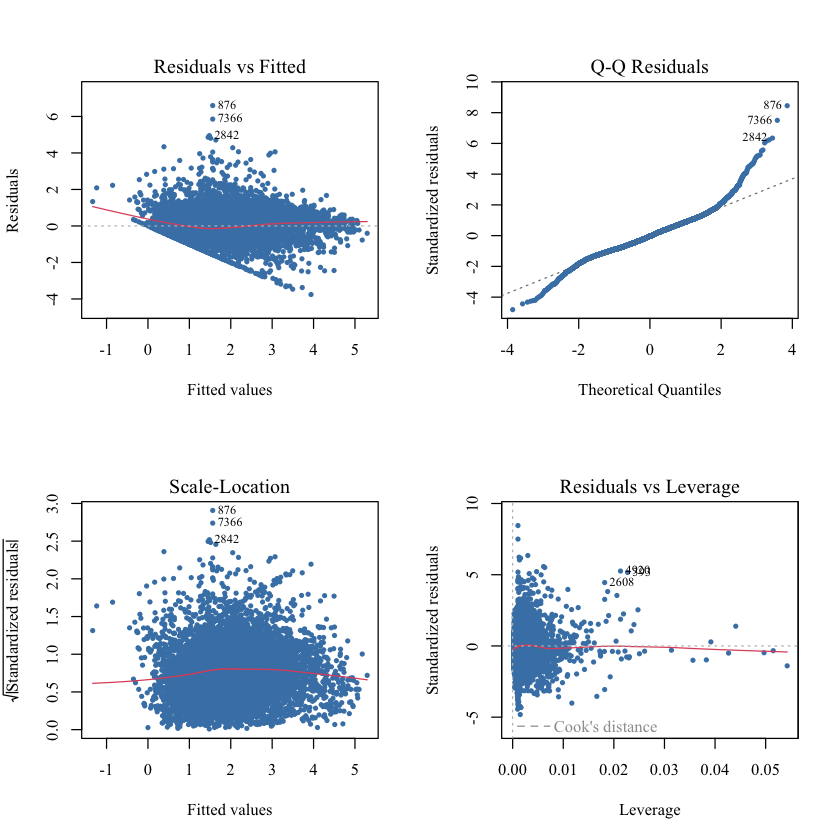

In [36]:
# ============================================================
# Check diagnostics for the final Stepwise-selected model
# ============================================================

par(mfrow = c(2, 2))
par(family = "Times New Roman")
plot(
  fit_step_log,
  col = "steelblue",   # point color
  pch = 16,            # solid circles
  cex = 0.7            # smaller points
)


### Diagnostic Plot Interpretation

The **Residuals vs Fitted** plot shows no strong systematic pattern, supporting the linearity assumption. A slight funnel shape is visible, suggesting mild heteroskedasticity.

The **Q–Q plot** indicates that residuals are approximately normal in the central region, although deviations in the tails suggest the presence of some extreme observations.

The **Scale–Location plot** shows a relatively stable spread of residuals, with a slight upward trend that further supports the presence of mild heteroskedasticity.

The **Residuals vs Leverage plot** indicates that most observations have low leverage. While a few points show higher leverage, there is no evidence of highly influential observations dominating the model.

Overall, while minor deviations from ideal assumptions are present, they are not severe, and the model remains appropriate for interpretation and prediction.


#### Breusch–Pagan Test for Heteroskedasticity

A Breusch–Pagan test was conducted to formally assess heteroskedasticity in the final Stepwise-selected model.


In [37]:
library(lmtest)
bptest(fit_step_log)


	studentized Breusch-Pagan test

data:  fit_step_log
BP = 170.24, df = 16, p-value < 2.2e-16


The Breusch–Pagan test evaluates whether residual variance is constant.

- **BP = 170.24**, **df = 16**, **p < 2.2e-16**

The very small p-value leads to rejection of the null hypothesis, indicating that **heteroskedasticity is present**. This is consistent with the residual plots, which show a slight increase in variance at higher fitted values.

Heteroskedasticity does not bias coefficient estimates, but it can affect standard errors, hypothesis tests, and confidence intervals. Therefore, coefficient-level inference should be interpreted with some caution, and robust standard errors could be considered as an extension.


#### Influence Analysis (Cook’s Distance)


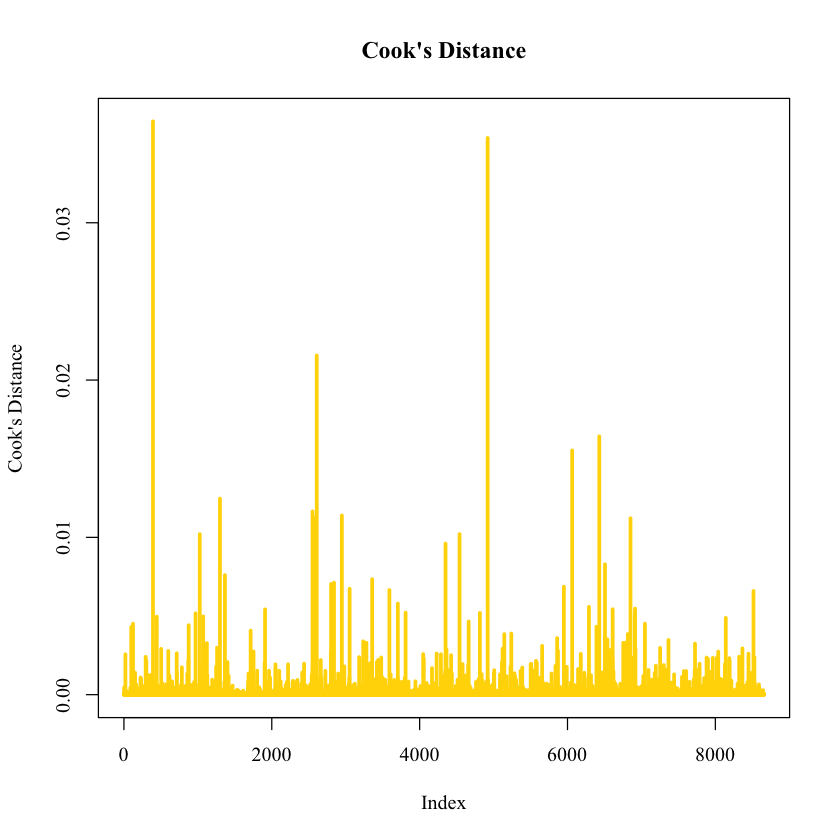

In [38]:
# Compute Cook’s distance for each observation in the final model
cook_values <- cooks.distance(fit_step_log)
par(family = "Times New Roman")
plot(cook_values,
     type = "h",
     lwd = 3,
     col = "gold",
     ylab = "Cook's Distance",
     main = "Cook's Distance")



Cook’s distance was examined to identify influential observations. While a small number of points exhibit higher influence, the majority of observations have very low Cook’s distance values.

This suggests that the model is not unduly driven by a few extreme observations, although some high-leverage points are present, which is expected in large real-world datasets.


#### Sensitivity Analysis (Influential Observations)

To assess whether influential observations affect the final conclusions, the top 1% most influential observations based on Cook’s distance are removed and the same model specification is re-estimated on the reduced dataset.


In [39]:
# ============================================================
# Sensitivity Analysis: Remove Influential Observations
# ============================================================

# Define a threshold using the 99th percentile of Cook's distance
# This identifies the top 1% most influential observations
threshold <- quantile(cook_values, 0.99)

# Remove observations above the Cook's distance threshold
# Keep only observations below the threshold
data_robust <- data_model[cook_values < threshold, ]

# Refit the same regression model on the reduced dataset
# using the same model formula as the final Stepwise-selected model
fit_robust <- lm(formula(fit_step_log), data = data_robust)

# Review the refitted model summary
summary(fit_robust)

# Compare coefficients between the original and sensitivity models
# Similar signs and magnitudes indicate stable results
coef_comparison <- cbind(
  Original = coef(fit_step_log),
  Robust = coef(fit_robust)
)

coef_comparison



Call:
lm(formula = formula(fit_step_log), data = data_robust)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.7749 -0.4961 -0.0187  0.4714  4.0154 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     -1.591e+01  3.723e-01 -42.730  < 2e-16 ***
log_income                       4.204e-01  3.497e-02  12.021  < 2e-16 ***
log_home_value                   9.795e-01  1.937e-02  50.578  < 2e-16 ***
log_ports                        1.267e-01  2.236e-02   5.664 1.53e-08 ***
poverty_rate                     7.374e-01  1.210e-01   6.096 1.14e-09 ***
bachelors_rate                   1.211e+00  1.335e-01   9.071  < 2e-16 ***
unemployment_rate                1.482e+00  1.852e-01   8.002 1.39e-15 ***
median_age                       1.473e-02  9.575e-04  15.386  < 2e-16 ***
car_commute_rate                -4.650e-01  7.525e-02  -6.179 6.75e-10 ***
transit_commute_rate            -2.991e+00  1.587e-01 -18.847  < 2e-16 ***
num

,Original,Robust
(Intercept),-15.573623967,-15.907258776
log_income,0.405115699,0.420371469
log_home_value,0.957775625,0.979521240
log_ports,0.126917316,0.126651867
poverty_rate,0.805322114,0.737374554
bachelors_rate,1.506440646,1.210716898
unemployment_rate,1.311931898,1.481514544
median_age,0.013457437,0.014732120
car_commute_rate,-0.310940741,-0.464970165
transit_commute_rate,-2.742929920,-2.991147159


#### Sensitivity Analysis Results

The estimated coefficients remain generally consistent in both **direction and magnitude** after removing the top 1% most influential observations.

Key variables such as income, home value, charging infrastructure, and commuting behavior retain their substantive interpretation. While a few coefficients, including education and commuting-related variables, show moderate changes in magnitude, these differences do not alter the main conclusions.

The adjusted R² is slightly higher in the reduced dataset, suggesting that the removed observations contributed additional variability. Overall, the main findings are **not driven by a small number of influential observations**, supporting the robustness of the final model.


### Final Model Results and Interpretation


In [40]:
summary(fit_step_log)


Call:
lm(formula = log_ev_prevalence ~ log_income + log_home_value + 
    log_ports + poverty_rate + bachelors_rate + unemployment_rate + 
    median_age + car_commute_rate + transit_commute_rate + num_dc_fast_ports + 
    dc_fast_ratio + network_count + has_dc_fast + charging_density_group + 
    workplace_charging_available, data = data_model)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.7569 -0.5111 -0.0296  0.4688  6.5970 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                     -15.573624   0.378779 -41.115  < 2e-16 ***
log_income                        0.405116   0.035961  11.265  < 2e-16 ***
log_home_value                    0.957776   0.020324  47.126  < 2e-16 ***
log_ports                         0.126917   0.023845   5.323 1.05e-07 ***
poverty_rate                      0.805322   0.117582   6.849 7.94e-12 ***
bachelors_rate                    1.506441   0.130536  11.540  < 2e-16 ***
unemployment_rate

### Model Interpretation

The final Stepwise-selected model explains a substantial portion of the variation in EV prevalence, with an **Adjusted R² of approximately 0.563**, indicating that about 56% of the variability in the log-transformed response is captured by the selected predictors. The model is highly significant overall (F-test p-value < 2.2e-16).

Because the response variable is log-transformed, coefficients represent **approximate percentage changes** in EV prevalence. Log-transformed predictors are interpreted as **elasticities**, while rate-based predictors reflect percentage-point effects.

Median income (**log_income**, β ≈ 0.405) shows a positive and statistically significant association: a 1% increase in median income is associated with approximately a **0.40% increase in EV prevalence**, holding other variables constant.

Median home value (**log_home_value**, β ≈ 0.958) exhibits the strongest elasticity, indicating that wealth-related factors are strongly associated with EV adoption.

Charging infrastructure (**log_ports**, β ≈ 0.127) is also positively associated, suggesting that greater availability of charging ports supports EV adoption.

Education (**bachelors_rate**, β ≈ 1.506) indicates that a one-percentage-point increase in the share of residents with a bachelor’s degree is associated with approximately a **1.5% increase in EV prevalence**, holding other variables constant.

Transit commute rate (β ≈ -2.743) shows a strong negative association: a one-percentage-point increase corresponds to approximately a **2.7% decrease in EV prevalence**, possibly reflecting lower reliance on private vehicle ownership in areas with higher public transit usage.

The presence of DC fast charging (**has_dc_fastYes**, β ≈ 0.134) is associated with approximately **13–14% higher EV prevalence**, relative to ZIP–state areas without fast-charging infrastructure, holding other variables constant.

The DC fast charging ratio (**dc_fast_ratio**, β ≈ -0.257) has a negative association, which may reflect differences in overall infrastructure composition rather than a direct negative effect of fast charging availability.

Because the model was selected using a stepwise procedure and mild heteroskedasticity is present, coefficient significance should be interpreted cautiously.

Overall, the results indicate that EV adoption is associated with economic capacity, infrastructure availability, education, and commuting behavior. These relationships should be interpreted as **associations rather than causal effects**, given the observational and cross-sectional nature of the data.


### Confidence Intervals for Model Coefficients

To further assess the reliability of the final model, 95% confidence intervals are computed for the coefficients of the Stepwise-selected model.

Confidence intervals complement p-values by providing a range of plausible values for each predictor’s effect, allowing a more informative assessment of both statistical and practical significance.

In this log-transformed model:

- Confidence intervals for log-transformed predictors represent plausible ranges for **elasticities**.
- Confidence intervals for non-log predictors represent plausible ranges for **approximate semi-elastic effects**.
- Intervals that do not include zero indicate statistical significance at the 5% level under the usual model assumptions.

Because mild heteroskedasticity is present, these intervals should be interpreted as useful evidence of precision, but robust standard errors could be considered for stricter inference.


In [41]:

# 95% confidence intervals
confint_95 <- confint(fit_step_log)

confint_95


,2.5 %,97.5 %
(Intercept),-16.316121537,-14.831126396
log_income,0.334623190,0.475608208
log_home_value,0.917935993,0.997615257
log_ports,0.080175765,0.173658868
poverty_rate,0.574834246,1.035809982
bachelors_rate,1.250559320,1.762321972
unemployment_rate,0.953815859,1.670047936
median_age,0.011503061,0.015411812
car_commute_rate,-0.462784525,-0.159096957
transit_commute_rate,-3.064501518,-2.421358321


### Interpretation of 95% Confidence Intervals

The 95% confidence intervals provide additional insight into the **precision and reliability** of the estimated coefficients.

#### Key Significant Predictors

Several key variables have intervals that exclude zero, indicating statistically significant and stable effects:

- **log_income**: (0.335, 0.476)  
  A 1% increase in income is associated with approximately **0.34% to 0.48% higher EV prevalence**.

- **log_home_value**: (0.918, 0.998)  
  A 1% increase in home value is associated with approximately **0.92% to 1.00% higher EV prevalence**, representing the strongest positive elasticity.

- **log_ports**: (0.080, 0.174)  
  A 1% increase in total charging ports is associated with approximately **0.08% to 0.17% higher EV prevalence**.

- **transit_commute_rate**: (-3.065, -2.421)  
  A one-percentage-point increase in transit commuting is associated with approximately a **2.4% to 3.0% decrease in EV prevalence**.

- **has_dc_fastYes**: (0.046, 0.222)  
  Relative to ZIP–state areas without DC fast charging, areas with at least one DC fast charger are associated with approximately **5% to 25% higher EV prevalence**.

#### Other Significant Effects

Variables such as **poverty_rate, bachelors_rate, unemployment_rate, and median_age** also have intervals that exclude zero, indicating statistically significant associations. These variables likely reflect broader socioeconomic and demographic patterns.

#### Weak or Uncertain Predictors

Some predictors have intervals that include zero, suggesting no clear statistical evidence of an effect at the 5% level:

- **charging_density_group**
- **workplace_charging_available**

These variables should be interpreted with caution.

#### Overall Interpretation

The confidence intervals reinforce the importance of key economic and infrastructure variables while highlighting a few predictors with weaker or uncertain effects. Together, they strengthen the interpretation of the final model while also showing where uncertainty remains.


### Additional Note on Considering Poisson Regression

As part of the modeling process, Poisson regression was considered because EV adoption originates from count data, specifically the number of electric vehicles.

However, the response variable used in this analysis is **EV prevalence**, defined as:

EV_Prevalence = (EV_count / population) × 1000

This is a **continuous rate**, not a raw count. In addition, the final model applies a log transformation to the response and selected predictors, which captures multiplicative relationships and helps stabilize variance.

Poisson regression is designed for discrete count outcomes and would require both:

- the raw EV count
- a population offset term

While such a specification is feasible, it would require restructuring the model and does not align directly with the current formulation based on prevalence.

Therefore, although Poisson regression was considered, the log-transformed linear model is more appropriate for the available data representation and provides a more direct and interpretable framework for analyzing variation in EV prevalence.


## Final Conclusion

This analysis examined factors associated with EV adoption across U.S. ZIP–state areas using a structured modeling workflow that included data cleaning, missingness assessment, transformation, diagnostic validation, variable selection, predictive evaluation, and interpretation.

The final model was selected using Stepwise AIC and estimated with a log-transformed response and selected log-transformed predictors. This specification improved model diagnostics, maintained interpretability, and performed slightly better than LASSO and Elastic Net in test-set prediction metrics.

Across the modeling process, several findings were consistent:

- **Economic capacity is strongly associated with EV adoption:** `log_income` and `log_home_value` are positive predictors, supporting the hypothesis that higher-income or higher-wealth areas tend to have higher EV adoption.
- **Education is important:** `bachelors_rate` is positively associated with EV prevalence, suggesting that educational attainment may reflect awareness, technology adoption, and environmental preferences.
- **Infrastructure availability is associated with adoption:** charging ports and DC fast charging availability are positively associated with EV prevalence, highlighting the role of accessibility.
- **Transportation behavior adds context:** commuting patterns are significantly related to EV prevalence, suggesting that local travel behavior influences adoption patterns.

The model was validated through several checks:

- diagnostic plots showed improved model behavior after transformation, with only mild remaining departures from ideal assumptions  
- the Breusch–Pagan test indicated heteroskedasticity, so coefficient-level inference should be interpreted with some caution  
- VIF results indicated no severe multicollinearity  
- train/test evaluation showed similar performance across models, with Stepwise slightly better  
- ANOVA confirmed that the reduced Stepwise model fits comparably to the full transformed model  
- sensitivity analysis showed that the main findings were not driven by the top 1% most influential observations

Although Poisson regression was considered, it was not used because the response variable represents a continuous rate rather than a count outcome. While a count-based specification with a population offset is possible, it does not align directly with the current formulation of EV prevalence. A log-transformed linear model is therefore more appropriate for the research objective.

Results should be interpreted as **associations rather than causal effects**, given the observational and cross-sectional nature of the data.

---

### Practical Implications

The results suggest that policies aimed at increasing EV adoption should focus on:

- expanding charging infrastructure, particularly fast-charging networks  
- improving affordability in lower-income areas through incentives or subsidies  
- increasing awareness and education around EV benefits  
- accounting for regional differences in transportation behavior and infrastructure  

---

### Limitations and Future Work

Despite strong findings, several limitations remain. 
- First, the model relies on available socioeconomic and infrastructure variables, and may omit relevant factors such as local policy incentives, fuel prices, or environmental attitudes.
- Second, the cross-sectional nature of the data limits the ability to capture temporal dynamics in EV adoption.
- Third, median imputation is transparent and robust but does not fully reflect uncertainty in missing values.
- Finally, stepwise model selection introduces additional uncertainty in coefficient interpretation.

Future work could extend this analysis by:

- incorporating additional variables such as policy incentives, gas prices, and urban density  
- using longitudinal or panel data to analyze changes in EV adoption over time  
- exploring nonlinear models or interaction effects between key predictors  
- applying spatial or regional models to capture geographic dependencies  
- considering robust standard errors or alternative modeling approaches for heteroskedasticity  

---

### Final Remark

Overall, EV adoption is associated with a combination of economic capacity, education, infrastructure availability, and transportation behavior. While income emerges as a key factor, substantial variation remains across ZIP–state areas. The final model provides a statistically sound and interpretable framework for understanding these relationships and offers a foundation for future research and policy design aimed at promoting equitable EV adoption.
